 # Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import zipfile for extraction
import zipfile

# Set the path to your new zip file in Google Drive
zip_path = "/content/drive/MyDrive/UTSW-Glioma.zip"

# Set extraction folder
extract_path = "/content/UTSW-Glioma"

# Extract the zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("UTSWGlioma extracted successfully")

UTSWGlioma extracted successfully


# Load Patient List

In [ ]:
import os
base_path = os.path.join(extract_path, "UTSW-Glioma")  # adjust if needed

patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT0695', 'BT0972', 'BT0823', 'BT0336', 'BT1060']


# Visualize MRI Slices

Showing images for: BT0695
Shape: (240, 240, 155)


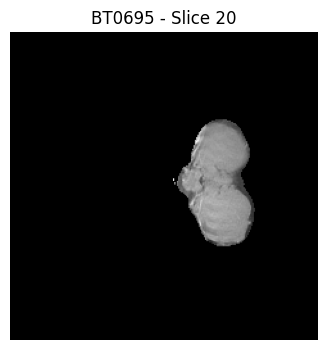

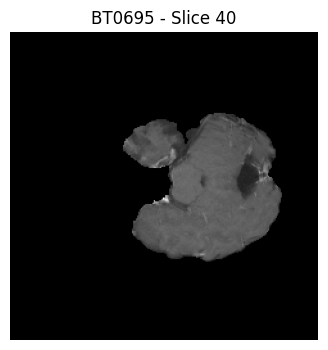

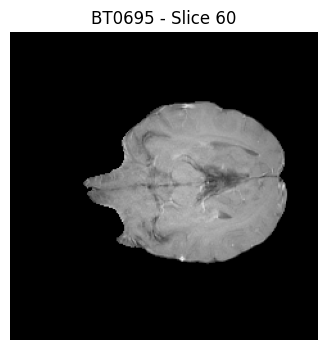

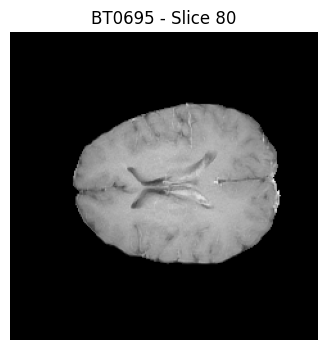

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

# Pick first patient
sample_patient = patients[0]
patient_path = os.path.join(base_path, sample_patient)

print("Showing images for:", sample_patient)

# Choose one modality (you can change this)
mri_path = os.path.join(patient_path, "brain_t1ce.nii.gz")

# Load MRI
img = nib.load(mri_path)
data = img.get_fdata()

print("Shape:", data.shape)

# Show multiple slices
slice_indices = [20, 40, 60, 80]

for i in slice_indices:
    if i < data.shape[2]:
        plt.figure(figsize=(4,4))
        plt.imshow(data[:, :, i], cmap="gray")
        plt.title(f"{sample_patient} - Slice {i}")
        plt.axis("off")
        plt.show()

# Verify Folder Structure

In [ ]:
import os

extract_path = "/content/UTSW-Glioma"

print("Level 1:", os.listdir(extract_path))

Level 1: ['UTSW-Glioma']


In [ ]:
inner = os.listdir(extract_path)[0]
print("Level 2:", os.listdir(os.path.join(extract_path, inner)))

Level 2: ['BT0695', 'BT0972', 'BT0823', 'BT0336', 'BT1060', 'BT1122', 'BT0950', 'BT0474', 'BT0712', 'BT0002', 'BT0363', 'BT0295', 'BT0656', 'BT1259', 'BT0961', 'BT0020', 'BT1010', 'BT0155', 'BT0840', 'BT0158', 'BT0300', 'BT0704', 'BT1301', 'BT0136', 'BT0089', 'BT0244', 'BT0667', 'BT1104', 'BT0828', 'BT1129', 'BT1114', 'BT0663', 'BT0065', 'BT0407', 'BT1067', 'BT1297', 'BT1125', 'BT0836', 'BT0277', 'BT0484', 'BT0424', 'BT1070', 'BT1098', 'BT1016', 'BT0498', 'BT0754', 'BT1079', 'BT0925', 'BT1102', 'BT0063', 'BT0066', 'BT0521', 'BT0084', 'BT1277', 'BT0452', 'BT0637', 'BT0767', 'BT0211', 'BT1038', 'BT0765', 'BT1099', 'BT0476', 'BT0287', 'BT1026', 'BT1146', 'BT0333', 'BT0466', 'BT1116', 'BT1035', 'BT0078', 'BT1108', 'BT0917', 'BT0957', 'BT0422', 'BT0610', 'BT1012', 'BT0463', 'BT0107', 'BT1092', 'BT0971', 'BT1137', 'BT1090', 'BT1000', 'BT1072', 'BT0764', 'BT0842', 'BT1041', 'BT0781', 'BT0083', 'BT0204', 'BT0138', 'BT0124', 'BT0465', 'BT0005', 'BT1234', 'BT0611', 'BT0227', 'BT0345', 'BT0145', 

5. Reload Patients

In [ ]:
import os

extract_path = "/content/UTSW-Glioma"

# Correct base path
base_path = os.path.join(extract_path, "UTSW-Glioma")

# Load patients
patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT0695', 'BT0972', 'BT0823', 'BT0336', 'BT1060']


# 6. Feature Extraction Function

In [ ]:
import numpy as np

def extract_features(image, mask=None, sample_size=5000):

    # Tumor region
    if mask is not None and np.sum(mask) > 0:
        pixels = image[mask > 0]

    # Non-tumor region (random sampling)
    else:
        flat = image.flatten()
        idx = np.random.choice(len(flat), min(sample_size, len(flat)), replace=False)
        pixels = flat[idx]

    # Safety check
    if len(pixels) == 0:
        return None

    # Feature extraction
    features = {
        "mean": float(np.mean(pixels)),
        "std": float(np.std(pixels)),
        "max": float(np.max(pixels)),
        "min": float(np.min(pixels)),
        "median": float(np.median(pixels)),
        "range": float(np.max(pixels) - np.min(pixels))
    }

    return features

# Dataset Creation (Multi-Modal) Create DataFrame & Clean Features

In [ ]:
# ===============================
# IMPORTS (IMPORTANT)
# ===============================
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to

# ===============================
# DATA STORAGE
# ===============================
data_list = []

# ===============================
# MULTI-MODAL FILES
# ===============================
modalities = {
    "t1": "brain_t1.nii.gz",
    "t1ce": "brain_t1ce.nii.gz",
    "t2": "brain_t2.nii.gz",
    "flair": "brain_flair.nii.gz"
}

# ===============================
# MAIN LOOP
# ===============================
for patient in patients:
    patient_path = os.path.join(base_path, patient)

    mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")

    if not os.path.exists(mask_path):
        continue

    try:
        # ------------------------------
        # LOAD MASK
        # ------------------------------
        mask_img = nib.load(mask_path)

        mri_data_all = {}
        ref_img = None

        # ------------------------------
        # LOAD ALL MRI MODALITIES
        # ------------------------------
        for key, file in modalities.items():
            path = os.path.join(patient_path, file)

            if os.path.exists(path):
                img = nib.load(path)
                mri_data_all[key] = img.get_fdata()

                if ref_img is None:
                    ref_img = img

        # Skip if no MRI
        if len(mri_data_all) == 0:
            continue

        # ------------------------------
        # RESAMPLE MASK
        # ------------------------------
        mask_resampled = resample_from_to(mask_img, ref_img, order=0)
        mask_data = mask_resampled.get_fdata()

        # ------------------------------
        # SAFE SLICE COUNT
        # ------------------------------
        num_slices = mask_data.shape[2]

        tumor_areas = np.array([
            mask_data[:, :, i].sum() for i in range(num_slices)
        ])

        # ==============================
        # TUMOR SAMPLES (label = 1)
        # ==============================
        tumor_slices = np.where(tumor_areas > 0)[0]

        for s in tumor_slices[:3]:

            feats = {}

            for mod, img in mri_data_all.items():

                # Safety check (IMPORTANT)
                if s >= img.shape[2]:
                    continue

                slice_img = img[:, :, s]

                f = extract_features(slice_img, mask_data[:, :, s])

                if f is not None:
                    for k, v in f.items():
                        feats[f"{mod}_{k}"] = v

            # Append only if features exist
            if len(feats) > 0:
                feats["label"] = 1
                feats["patient"] = patient
                data_list.append(feats)

        # ==============================
        # NON-TUMOR SAMPLES (label = 0)
        # ==============================
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        if len(non_tumor_slices) > 0:

            step = max(1, len(non_tumor_slices)//3)

            for s in non_tumor_slices[::step][:3]:

                feats = {}

                for mod, img in mri_data_all.items():

                    # Safety check
                    if s >= img.shape[2]:
                        continue

                    slice_img = img[:, :, s]

                    f = extract_features(slice_img, None)

                    if f is not None:
                        for k, v in f.items():
                            feats[f"{mod}_{k}"] = v

                if len(feats) > 0:
                    feats["label"] = 0
                    feats["patient"] = patient
                    data_list.append(feats)

    except Exception as e:
        print(f"Skipping {patient}: {e}")

# ===============================
# CREATE DATAFRAME
# ===============================
df = pd.DataFrame(data_list)

print("Before cleaning:", df.shape)

# -------------------------------
# REMOVE ZERO FEATURE ROWS
# -------------------------------
feature_cols = [col for col in df.columns if col not in ["label", "patient"]]

df = df[(df[feature_cols] != 0).any(axis=1)]

print("After cleaning:", df.shape)

# -------------------------------
# CHECK DISTRIBUTION AGAIN
# -------------------------------
print("\nLabel distribution:\n", df["label"].value_counts())
print("\nSample data:\n", df.head())

Before cleaning: (2136, 26)
After cleaning: (2048, 26)

Label distribution:
 label
1    1037
0    1011
Name: count, dtype: int64

Sample data:
       t1_mean     t1_std      t1_max      t1_min   t1_median    t1_range  \
0  339.093163  26.659099  374.465668  246.528046  338.583435  127.937622   
1  357.019339  11.144805  374.120972  340.151520  357.061646   33.969452   
2  360.201988  11.102185  378.131012  338.229187  360.393219   39.901825   
3    2.324163  28.343466  464.766907    0.000000    0.000000  464.766907   
4   29.788643  96.285741  432.092041    0.000000    0.000000  432.092041   

    t1ce_mean    t1ce_std    t1ce_max    t1ce_min  ...   t2_median  \
0  385.490612   32.993996  473.123077  333.906281  ...  607.599792   
1  385.172326   11.851400  405.321136  361.946564  ...  613.071899   
2  388.577277   16.810305  438.263763  359.855865  ...  615.632751   
3    2.211821   29.721657  595.645447    0.000000  ...    0.000000   
4   29.048140  100.561635  583.951904    0.000000

In [ ]:
# Remove rows with too many zero values (optional but recommended)
feature_cols = [c for c in df.columns if c not in ["label", "patient"]]

zero_fraction = (df[feature_cols] == 0).sum(axis=1) / len(feature_cols)

# Keep rows where less than 50% features are zero
df = df[zero_fraction < 0.5]

print("After zero-filter:", df.shape)
print(df["label"].value_counts())

After zero-filter: (2026, 26)
label
1    1037
0     989
Name: count, dtype: int64


# Data Cleaning

In [ ]:
# ==========================================
# 5(a). DATA CLEANING
# ==========================================

print("Dataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Summary statistics
print("\nStatistical Summary:\n", df.describe())

# Check zero-value rows
zero_rows = (df == 0).sum().sum()
print("\nTotal Zero Values:", zero_rows)

Dataset Shape: (2026, 26)

Missing Values:
 t1_mean         0
t1_std          0
t1_max          0
t1_min          0
t1_median       0
t1_range        0
t1ce_mean       0
t1ce_std        0
t1ce_max        0
t1ce_min        0
t1ce_median     0
t1ce_range      0
t2_mean         0
t2_std          0
t2_max          0
t2_min          0
t2_median       0
t2_range        0
flair_mean      0
flair_std       0
flair_max       0
flair_min       0
flair_median    0
flair_range     0
label           0
patient         0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
              t1_mean         t1_std         t1_max         t1_min  \
count    2026.000000    2026.000000    2026.000000    2026.000000   
mean     2428.739478     685.992182    5455.995872    1826.939119   
std     19537.571145    5496.410993   36010.345117   16411.799883   
min         0.040566       0.000000     119.435875       0.000000   
25%        48.846478      21.420011     411.123238       0.000000   
50%       264.53776

# Basic Data Inspection and Outlier Detection Using IQR Method

<class 'pandas.core.frame.DataFrame'>
Index: 2026 entries, 0 to 2135
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   t1_mean       2026 non-null   float64
 1   t1_std        2026 non-null   float64
 2   t1_max        2026 non-null   float64
 3   t1_min        2026 non-null   float64
 4   t1_median     2026 non-null   float64
 5   t1_range      2026 non-null   float64
 6   t1ce_mean     2026 non-null   float64
 7   t1ce_std      2026 non-null   float64
 8   t1ce_max      2026 non-null   float64
 9   t1ce_min      2026 non-null   float64
 10  t1ce_median   2026 non-null   float64
 11  t1ce_range    2026 non-null   float64
 12  t2_mean       2026 non-null   float64
 13  t2_std        2026 non-null   float64
 14  t2_max        2026 non-null   float64
 15  t2_min        2026 non-null   float64
 16  t2_median     2026 non-null   float64
 17  t2_range      2026 non-null   float64
 18  flair_mean    2026 non-null   flo

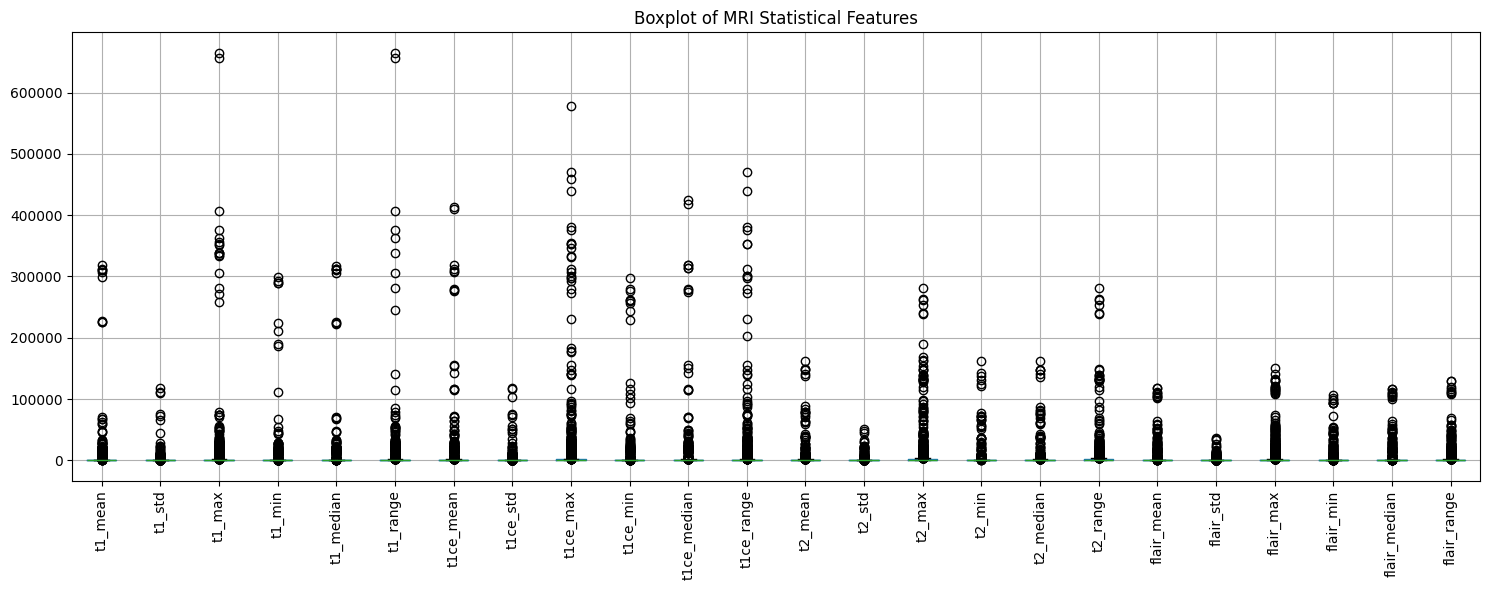

In [ ]:
# ===============================
# BASIC DATA CHECKS
# ===============================

print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())


# ==========================================
# OUTLIER DETECTION USING IQR METHOD
# ==========================================

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    # Skip target label
    if col == "label":
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_count = outliers.shape[0]

    outlier_percent = (
        outlier_count / df.shape[0]
    ) * 100

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier Percent": round(outlier_percent, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

print("\nOUTLIER SUMMARY")
print(
    outlier_df.sort_values(
        by="Outlier Percent",
        ascending=False
    )
)


# ==========================================
# BOXPLOT VISUALIZATION
# ==========================================

plt.figure(figsize=(15,6))

df[numeric_cols.drop("label")].boxplot(rot=90)

plt.title("Boxplot of MRI Statistical Features")

plt.tight_layout()

plt.savefig(
    "outlier_boxplot.png",
    bbox_inches='tight'
)

plt.show()

# Exploratory Data Analysis (EDA)

# Class Distribution

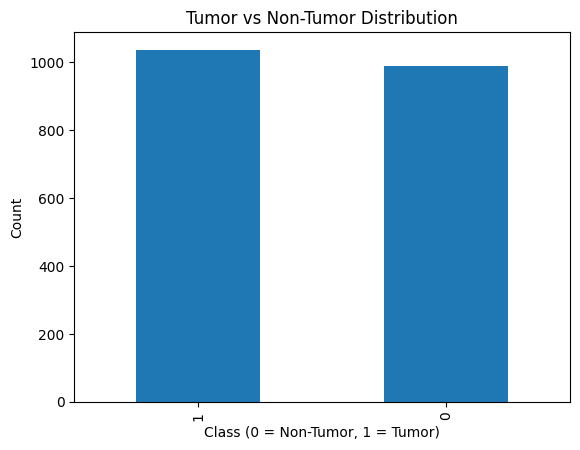

In [ ]:
# ==========================================
# 5(b). EDA - CLASS DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Tumor vs Non-Tumor Distribution")
plt.xlabel("Class (0 = Non-Tumor, 1 = Tumor)")
plt.ylabel("Count")
plt.show()

# Feature Distribution

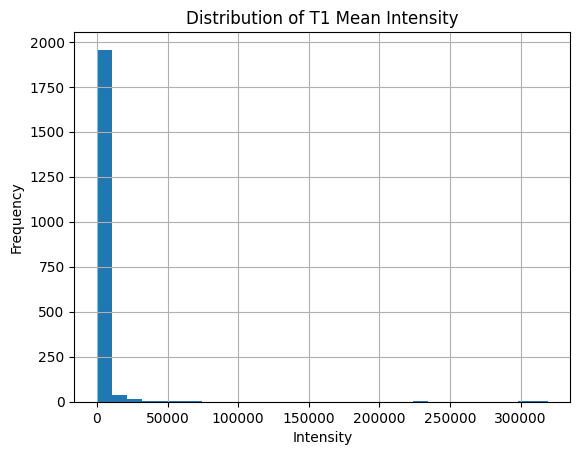

In [ ]:
# ==========================================
# 5(b). EDA - FEATURE DISTRIBUTION
# ==========================================

df["t1_mean"].hist(bins=30)
plt.title("Distribution of T1 Mean Intensity")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap

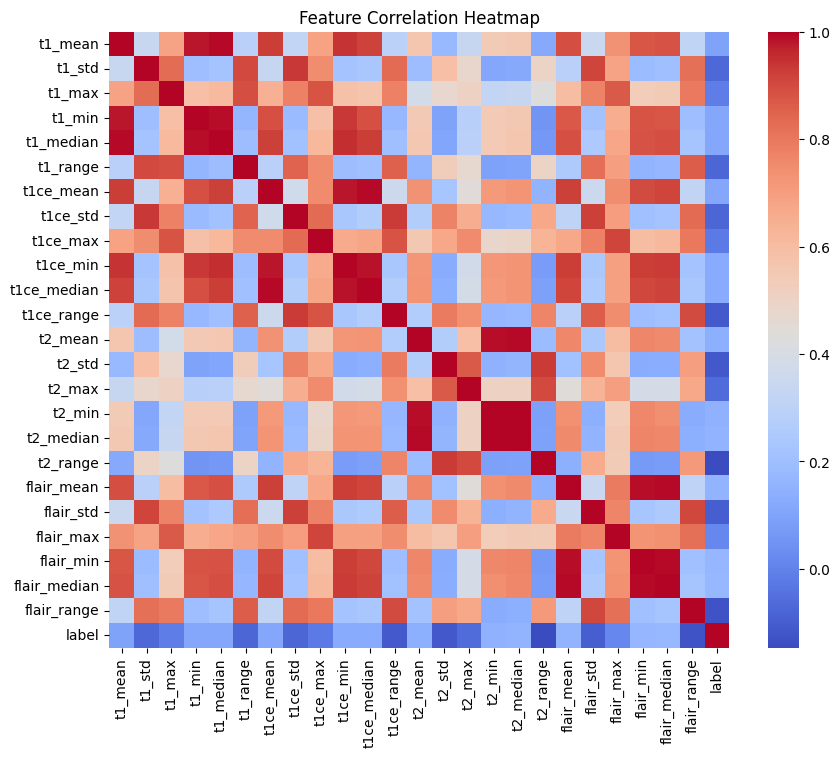

In [ ]:
# ==========================================
# 5(b). EDA - CORRELATION HEATMAP (FIXED)
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

# Patient-Wise Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Get unique patients with their labels
patient_labels = df.groupby("patient")["label"].max().reset_index()

train_p, test_p = train_test_split(
    patient_labels["patient"],
    test_size=0.3,
    random_state=42,
    stratify=patient_labels["label"]  # 🔥 important
)

# Split dataset
train_df = df[df["patient"].isin(train_p)]
test_df = df[df["patient"].isin(test_p)]

# Features & target
X_train = train_df.drop(["label", "patient"], axis=1)
y_train = train_df["label"]

X_test = test_df.drop(["label", "patient"], axis=1)
y_test = test_df["label"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())

Train shape: (1410, 24)
Test shape: (616, 24)

Train label distribution:
 label
1    722
0    688
Name: count, dtype: int64

Test label distribution:
 label
1    315
0    301
Name: count, dtype: int64


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# XGBoost Model Training

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    eval_metric="logloss"
)

# Train with validation (early stopping)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# XGBoost Evaluation

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9935275080906149

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       303
           1       1.00      0.99      0.99       315

    accuracy                           0.99       618
   macro avg       0.99      0.99      0.99       618
weighted avg       0.99      0.99      0.99       618



# GroupKFold Validation

In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=5)
scores = []

X = df.drop(columns=["label","patient"])
y = df["label"]
groups = df["patient"]

for tr, va in gkf.split(X, y, groups):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    Xtr = scaler.fit_transform(Xtr)
    Xva = scaler.transform(Xva)

    m = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    m.fit(Xtr, ytr)
    scores.append(m.score(Xva, yva))

print("GroupKFold Accuracy:", np.mean(scores))

GroupKFold Accuracy: 0.9916134525329927


# Confusion Matrix

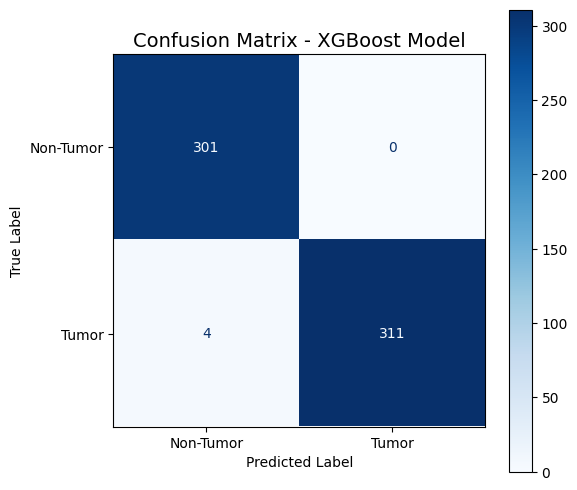

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using trained model
y_pred = model.predict(X_test)

# Import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display with labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Tumor", "Tumor"]
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True
)

plt.title(
    "Confusion Matrix - XGBoost Model",
    fontsize=14
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.grid(False)

plt.show()

# ROC Curve

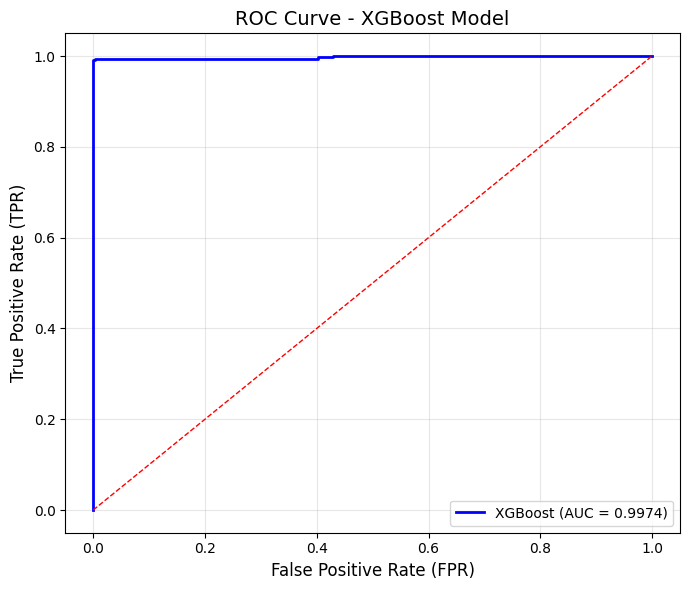

ROC-AUC Score: 0.9973527395454306


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f"XGBoost (AUC = {roc_auc:.4f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1)

# Labels & title
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("ROC Curve - XGBoost Model", fontsize=14)

# Legend
plt.legend(loc="lower right")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC
print("ROC-AUC Score:", roc_auc)

# Feature Importance

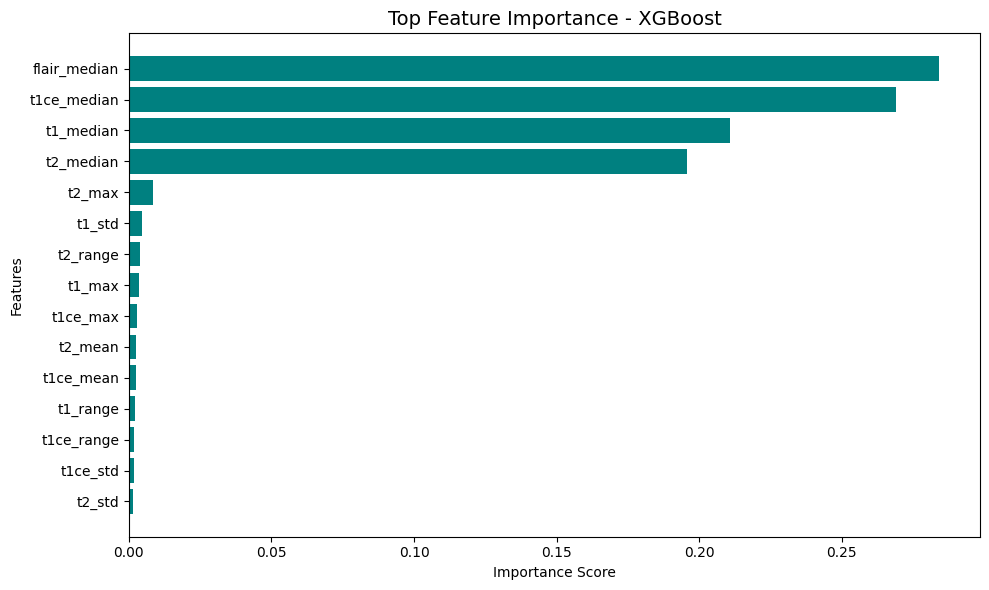

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature names from dataframe
feature_names = X.columns  # IMPORTANT

# Get importance values
importances = model.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Select top 15 features (clean visualization)
top_n = 15
feat_df_top = feat_df.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df_top["Feature"], feat_df_top["Importance"], color="teal")
plt.gca().invert_yaxis()

plt.title("Top Feature Importance - XGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# ML Model Comparison

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier
import pandas as pd

# ===============================
# MODELS (OPTIMIZED)
# ===============================
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        C=1.0
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# ===============================
# TRAIN + EVALUATE
# ===============================
results = []

for name, model in models.items():

    # ---------------------------
    # TRAIN MODEL
    # ---------------------------
    model.fit(X_train, y_train)

    # ---------------------------
    # PREDICTIONS
    # ---------------------------
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # ---------------------------
    # METRICS
    # ---------------------------
    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # ---------------------------
    # STORE RESULTS
    # ---------------------------
    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    # ---------------------------
    # PRINT RESULTS
    # ---------------------------
    print(
        f"{name}: "
        f"Accuracy = {acc:.4f}, "
        f"AUC = {auc:.4f}, "
        f"Precision = {precision:.4f}, "
        f"Recall = {recall:.4f}, "
        f"F1 = {f1:.4f}"
    )

# ===============================
# RESULT TABLE
# ===============================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nFinal Comparison:\n")

print(results_df.to_string(index=False))

Logistic Regression: Accuracy = 0.9789, AUC = 0.9977, Precision = 1.0000, Recall = 0.9587, F1 = 0.9789
SVM: Accuracy = 0.9708, AUC = 0.9879, Precision = 1.0000, Recall = 0.9429, F1 = 0.9706
KNN: Accuracy = 0.9919, AUC = 0.9936, Precision = 1.0000, Recall = 0.9841, F1 = 0.9920
Random Forest: Accuracy = 0.9919, AUC = 0.9990, Precision = 1.0000, Recall = 0.9841, F1 = 0.9920
Gradient Boosting: Accuracy = 0.9935, AUC = 0.9974, Precision = 1.0000, Recall = 0.9873, F1 = 0.9936
XGBoost: Accuracy = 0.9935, AUC = 0.9973, Precision = 1.0000, Recall = 0.9873, F1 = 0.9936

Final Comparison:

              Model  Accuracy  ROC-AUC  Precision   Recall  F1-Score
  Gradient Boosting  0.993506 0.997432        1.0 0.987302  0.993610
            XGBoost  0.993506 0.997342        1.0 0.987302  0.993610
      Random Forest  0.991883 0.998993        1.0 0.984127  0.992000
                KNN  0.991883 0.993588        1.0 0.984127  0.992000
Logistic Regression  0.978896 0.997732        1.0 0.958730  0.978930


# Final Model Comparison Table

In [ ]:
# ==========================================
# FINAL MODEL COMPARISON TABLE
# ==========================================

import pandas as pd

# -------------------------------
# CONVERT RESULTS TO DATAFRAME
# -------------------------------
results_df = pd.DataFrame(results)

# -------------------------------
# SORT RESULTS
# -------------------------------
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# RESET INDEX
# -------------------------------
results_df = results_df.reset_index(drop=True)

# -------------------------------
# ROUND VALUES FOR CLEAN DISPLAY
# -------------------------------
results_df = results_df.round({
    "Accuracy": 4,
    "ROC-AUC": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 4
})

# -------------------------------
# DISPLAY FINAL TABLE
# -------------------------------
print("\n" + "="*70)
print("FINAL MODEL COMPARISON TABLE")
print("="*70)

print(results_df.to_string(index=False))


FINAL MODEL COMPARISON TABLE
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
  Gradient Boosting    0.9935   0.9974        1.0  0.9873    0.9936
            XGBoost    0.9935   0.9973        1.0  0.9873    0.9936
      Random Forest    0.9919   0.9990        1.0  0.9841    0.9920
                KNN    0.9919   0.9936        1.0  0.9841    0.9920
Logistic Regression    0.9789   0.9977        1.0  0.9587    0.9789
                SVM    0.9708   0.9879        1.0  0.9429    0.9706


# Create Deep Learning Image Dataset

In [ ]:
import os
import cv2
import nibabel as nib
import numpy as np
from nibabel.processing import resample_from_to

# ===============================
# OUTPUT FOLDERS
# ===============================
img_dir = "/content/dl_dataset"
os.makedirs(os.path.join(img_dir, "tumor"), exist_ok=True)
os.makedirs(os.path.join(img_dir, "non_tumor"), exist_ok=True)

saved_count = 0

# ===============================
# MAIN LOOP (INCREASE PATIENTS)
# ===============================
for patient in patients[:150]:  # 🔥 increased from 50 → 150
    p_path = os.path.join(base_path, patient)

    mri_path = os.path.join(p_path, "brain_t1ce.nii.gz")
    mask_path = os.path.join(p_path, "tumorseg_manual_correction.nii.gz")

    if not (os.path.exists(mri_path) and os.path.exists(mask_path)):
        continue

    try:
        # ------------------------------
        # LOAD MRI
        # ------------------------------
        mri_img = nib.load(mri_path)
        mri = mri_img.get_fdata()

        # ------------------------------
        # LOAD + RESAMPLE MASK
        # ------------------------------
        mask_img = nib.load(mask_path)
        mask_resampled = resample_from_to(mask_img, mri_img, order=0)
        mask = mask_resampled.get_fdata()

        num_slices = min(mri.shape[2], mask.shape[2])

        # ------------------------------
        # FIND TUMOR SLICES
        # ------------------------------
        tumor_areas = np.array([np.sum(mask[:, :, i]) for i in range(num_slices)])

        tumor_slices = np.where(tumor_areas > 0)[0]
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        # ===============================
        # SAVE TUMOR IMAGES (MORE SAMPLES)
        # ===============================
        for i in tumor_slices[:10]:  # 🔥 increased from 5 → 10

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

        # ===============================
        # SAVE NON-TUMOR IMAGES (BALANCED)
        # ===============================
        step = max(1, len(non_tumor_slices)//10)

        for i in non_tumor_slices[::step][:10]:  # 🔥 increased

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

    except Exception as e:
        print(f"Skipping {patient}: {e}")

print("Total images saved:", saved_count)

Total images saved: 3352


# Count Saved Images

In [ ]:
print(len(os.listdir(img_dir + "/tumor")))
print(len(os.listdir(img_dir + "/non_tumor")))

1740
1612


# ResNet Training

In [ ]:


# ===============================
# IMPORTS
# ===============================
import torch
import torchvision

from torchvision import datasets, transforms

from torch.utils.data import (
    DataLoader,
    random_split
)

from torch import nn, optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    # ---------------------------
    # DATA AUGMENTATION
    # ---------------------------
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5]*3,
        [0.5]*3
    )
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"

dataset = datasets.ImageFolder(
    data_dir,
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size]
)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ===============================
# MODEL (TRANSFER LEARNING)
# ===============================
resnet = torchvision.models.resnet18(
    weights="IMAGENET1K_V1"
)

# -------------------------------
# FREEZE BACKBONE
# -------------------------------
for param in resnet.parameters():
    param.requires_grad = False

# -------------------------------
# REPLACE FINAL CLASSIFIER
# -------------------------------
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    2
)

# -------------------------------
# SEND MODEL TO DEVICE
# -------------------------------
resnet = resnet.to(device)

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

# ===============================
# OPTIMIZER
# ===============================
optimizer = optim.Adam(
    resnet.fc.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):

    resnet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # -----------------------
        # RESET GRADIENTS
        # -----------------------
        optimizer.zero_grad()

        # -----------------------
        # FORWARD PASS
        # -----------------------
        outputs = resnet(images)

        # -----------------------
        # LOSS
        # -----------------------
        loss = criterion(outputs, labels)

        # -----------------------
        # BACKPROPAGATION
        # -----------------------
        loss.backward()

        optimizer.step()

        # -----------------------
        # TRACK LOSS
        # -----------------------
        running_loss += loss.item()

        # -----------------------
        # TRAIN ACCURACY
        # -----------------------
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

# ===============================
# EVALUATION
# ===============================
resnet.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet(images)

        # -----------------------
        # PROBABILITIES
        # -----------------------
        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        # -----------------------
        # PREDICTIONS
        # -----------------------
        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

# ===============================
# METRICS
# ===============================
acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds
)

recall = recall_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

auc = roc_auc_score(
    all_labels,
    all_probs
)

# ===============================
# DISPLAY RESULTS
# ===============================
print("\n" + "="*60)
print("RESNET18 FINAL RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds
    )
)

# ===============================
# CONFUSION MATRIX
# ===============================
print("Confusion Matrix:\n")

print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

Using device: cuda
Total images: 3352
Classes: ['non_tumor', 'tumor']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


Epoch 1/5 | Loss: 53.9714 | Train Accuracy: 0.6386
Epoch 2/5 | Loss: 47.4286 | Train Accuracy: 0.7285
Epoch 3/5 | Loss: 44.7648 | Train Accuracy: 0.7464
Epoch 4/5 | Loss: 43.8488 | Train Accuracy: 0.7508
Epoch 5/5 | Loss: 42.2850 | Train Accuracy: 0.7624

RESNET18 FINAL RESULTS
Accuracy  : 0.7690
Precision : 0.7347
Recall    : 0.8496
F1-Score  : 0.7880
ROC-AUC   : 0.8143

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.69      0.75       332
           1       0.73      0.85      0.79       339

    accuracy                           0.77       671
   macro avg       0.78      0.77      0.77       671
weighted avg       0.78      0.77      0.77       671

Confusion Matrix:

[[228 104]
 [ 51 288]]


# EfficientNet Training

In [ ]:
# ==========================================
# EFFICIENTNET-B0 TRANSFER LEARNING - UPDATED
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torch
import torchvision

from torchvision import datasets, transforms

from torch.utils.data import (
    DataLoader,
    random_split
)

from torch import nn, optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    # ---------------------------
    # DATA AUGMENTATION
    # ---------------------------
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5]*3,
        [0.5]*3
    )
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"

dataset = datasets.ImageFolder(
    data_dir,
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size]
)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ===============================
# MODEL (EFFICIENTNET-B0)
# ===============================
efficientnet = torchvision.models.efficientnet_b0(
    weights="IMAGENET1K_V1"
)

# -------------------------------
# FREEZE BACKBONE
# -------------------------------
for param in efficientnet.parameters():
    param.requires_grad = False

# -------------------------------
# REPLACE CLASSIFIER
# -------------------------------
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    2
)

# -------------------------------
# SEND MODEL TO DEVICE
# -------------------------------
efficientnet = efficientnet.to(device)

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

# ===============================
# OPTIMIZER
# ===============================
optimizer = optim.Adam(
    efficientnet.classifier.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):

    efficientnet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # -----------------------
        # RESET GRADIENTS
        # -----------------------
        optimizer.zero_grad()

        # -----------------------
        # FORWARD PASS
        # -----------------------
        outputs = efficientnet(images)

        # -----------------------
        # LOSS
        # -----------------------
        loss = criterion(outputs, labels)

        # -----------------------
        # BACKPROPAGATION
        # -----------------------
        loss.backward()

        optimizer.step()

        # -----------------------
        # TRACK LOSS
        # -----------------------
        running_loss += loss.item()

        # -----------------------
        # TRAIN ACCURACY
        # -----------------------
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

# ===============================
# EVALUATION
# ===============================
efficientnet.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = efficientnet(images)

        # -----------------------
        # PROBABILITIES
        # -----------------------
        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        # -----------------------
        # PREDICTIONS
        # -----------------------
        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

# ===============================
# METRICS
# ===============================
acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds
)

recall = recall_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

auc = roc_auc_score(
    all_labels,
    all_probs
)

# ===============================
# DISPLAY RESULTS
# ===============================
print("\n" + "="*60)
print("EFFICIENTNET-B0 FINAL RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds
    )
)

# ===============================
# CONFUSION MATRIX
# ===============================
print("Confusion Matrix:\n")

print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

Using device: cuda
Total images: 3352
Classes: ['non_tumor', 'tumor']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.6MB/s]


Epoch 1/5 | Loss: 52.4047 | Train Accuracy: 0.6830
Epoch 2/5 | Loss: 45.5863 | Train Accuracy: 0.7486
Epoch 3/5 | Loss: 43.2043 | Train Accuracy: 0.7617
Epoch 4/5 | Loss: 42.3433 | Train Accuracy: 0.7710
Epoch 5/5 | Loss: 41.1465 | Train Accuracy: 0.7743

EFFICIENTNET-B0 FINAL RESULTS
Accuracy  : 0.7765
Precision : 0.7333
Recall    : 0.8761
F1-Score  : 0.7984
ROC-AUC   : 0.8343

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.67      0.75       332
           1       0.73      0.88      0.80       339

    accuracy                           0.78       671
   macro avg       0.79      0.78      0.77       671
weighted avg       0.79      0.78      0.77       671

Confusion Matrix:

[[224 108]
 [ 42 297]]


# Deep Learning Evaluation Function

In [ ]:
# ==========================================
# DEEP LEARNING MODEL EVALUATION FUNCTION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import torch
import numpy as np

# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate_model(model, name="Model"):

    # -------------------------------
    # EVALUATION MODE
    # -------------------------------
    model.eval()

    # -------------------------------
    # STORAGE
    # -------------------------------
    all_preds = []

    all_labels = []

    all_probs = []

    # -------------------------------
    # DISABLE GRADIENTS
    # -------------------------------
    with torch.no_grad():

        for images, labels in test_loader:

            # -----------------------
            # SEND TO DEVICE
            # -----------------------
            images = images.to(device)

            # -----------------------
            # MODEL OUTPUT
            # -----------------------
            outputs = model(images)

            # -----------------------
            # PROBABILITIES
            # -----------------------
            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            # -----------------------
            # PREDICTIONS
            # -----------------------
            _, preds = torch.max(
                outputs,
                1
            )

            # -----------------------
            # STORE RESULTS
            # -----------------------
            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    # ======================================
    # METRICS
    # ======================================
    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds
    )

    recall = recall_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds
    )

    auc = roc_auc_score(
        all_labels,
        all_probs
    )

    # ======================================
    # DISPLAY RESULTS
    # ======================================
    print("\n" + "="*60)

    print(f"{name} FINAL RESULTS")

    print("="*60)

    print(f"Accuracy  : {acc:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1-Score  : {f1:.4f}")

    print(f"ROC-AUC   : {auc:.4f}")

    # ======================================
    # CLASSIFICATION REPORT
    # ======================================
    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds
        )
    )

    # ======================================
    # CONFUSION MATRIX
    # ======================================
    print("Confusion Matrix:\n")

    print(
        confusion_matrix(
            all_labels,
            all_preds
        )
    )

    # ======================================
    # RETURN RESULTS
    # ======================================
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    }

# Final DL Results

In [ ]:
# ==========================================
# FINAL DEEP LEARNING MODEL EVALUATION
# ==========================================

# -------------------------------
# EVALUATE RESNET
# -------------------------------
resnet_results = evaluate_model(
    resnet,
    "ResNet"
)

# -------------------------------
# EVALUATE EFFICIENTNET
# -------------------------------
effnet_results = evaluate_model(
    efficientnet,
    "EfficientNet"
)

# ==========================================
# CREATE FINAL DL RESULTS TABLE
# ==========================================
import pandas as pd

dl_results_df = pd.DataFrame([
    resnet_results,
    effnet_results
])

# -------------------------------
# SORT RESULTS
# -------------------------------
dl_results_df = dl_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# ROUND VALUES
# -------------------------------
dl_results_df = dl_results_df.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 4,
    "ROC-AUC": 4
})

# ==========================================
# DISPLAY FINAL RESULTS
# ==========================================
print("\n" + "="*80)

print("FINAL DEEP LEARNING RESULTS")

print("="*80)

print(
    dl_results_df.to_string(index=False)
)


ResNet FINAL RESULTS
Accuracy  : 0.7541
Precision : 0.7242
Recall    : 0.8289
F1-Score  : 0.7730
ROC-AUC   : 0.8137

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.68      0.73       332
           1       0.72      0.83      0.77       339

    accuracy                           0.75       671
   macro avg       0.76      0.75      0.75       671
weighted avg       0.76      0.75      0.75       671

Confusion Matrix:

[[225 107]
 [ 58 281]]

EfficientNet FINAL RESULTS
Accuracy  : 0.7765
Precision : 0.7299
Recall    : 0.8850
F1-Score  : 0.8000
ROC-AUC   : 0.8365

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.67      0.75       332
           1       0.73      0.88      0.80       339

    accuracy                           0.78       671
   macro avg       0.79      0.78      0.77       671
weighted avg       0.79      0.78      0.77       671

Confusion Matr

# Fixed Dataset Preparation

In [ ]:
# ==========================================
# FIXED DEEP LEARNING DATASET PREPARATION
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torch

from torchvision import (
    transforms,
    datasets
)

from torch.utils.data import (
    DataLoader,
    random_split
)

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ===============================
# TRANSFORMS
# ===============================
transform = transforms.Compose([

    # ---------------------------
    # CONVERT TO 3-CHANNEL IMAGE
    # ---------------------------
    transforms.Grayscale(
        num_output_channels=3
    ),

    # ---------------------------
    # RESIZE FOR PRETRAINED CNNs
    # ---------------------------
    transforms.Resize((224, 224)),

    # ---------------------------
    # DATA AUGMENTATION
    # ---------------------------
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    # ---------------------------
    # CONVERT TO TENSOR
    # ---------------------------
    transforms.ToTensor(),

    # ---------------------------
    # NORMALIZATION
    # ---------------------------
    transforms.Normalize(
        [0.5]*3,
        [0.5]*3
    )
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

# ===============================
# DATASET INFORMATION
# ===============================
print("\n" + "="*50)

print("DATASET INFORMATION")

print("="*50)

print("Total images:", len(dataset))

print("Classes:", dataset.classes)

print("Class Mapping:", dataset.class_to_idx)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(
    0.8 * len(dataset)
)

test_size = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size]
)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ===============================
# DISPLAY SPLIT INFORMATION
# ===============================
print("\n" + "="*50)

print("TRAIN / TEST SPLIT")

print("="*50)

print("Train size:", len(train_ds))

print("Test size:", len(test_ds))

# ===============================
# BATCH CHECK
# ===============================
images, labels = next(iter(train_loader))

print("\nSample Batch Shape:", images.shape)

print("Sample Labels Shape:", labels.shape)

Using device: cuda

DATASET INFORMATION
Total images: 3352
Classes: ['non_tumor', 'tumor']
Class Mapping: {'non_tumor': 0, 'tumor': 1}

TRAIN / TEST SPLIT
Train size: 2681
Test size: 671

Sample Batch Shape: torch.Size([32, 3, 224, 224])
Sample Labels Shape: torch.Size([32])


# Load ResNet Model

In [ ]:
# ==========================================
# RESNET18 MODEL PREPARATION
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torchvision

from torch import nn

# ===============================
# LOAD PRETRAINED RESNET18
# ===============================
resnet = torchvision.models.resnet18(
    weights="IMAGENET1K_V1"
)

# ===============================
# FREEZE FEATURE EXTRACTOR
# ===============================
for param in resnet.parameters():

    param.requires_grad = False

# ===============================
# GET INPUT FEATURES
# ===============================
num_features = resnet.fc.in_features

print("ResNet FC Input Features:", num_features)

# ===============================
# REPLACE FINAL CLASSIFIER
# ===============================
resnet.fc = nn.Sequential(

    # ---------------------------
    # DROPOUT FOR REGULARIZATION
    # ---------------------------
    nn.Dropout(0.3),

    # ---------------------------
    # FINAL CLASSIFICATION LAYER
    # ---------------------------
    nn.Linear(
        num_features,
        2
    )
)

# ===============================
# SEND MODEL TO DEVICE
# ===============================
resnet = resnet.to(device)

# ===============================
# DISPLAY MODEL SUMMARY
# ===============================
print("\n" + "="*50)

print("RESNET18 MODEL READY")

print("="*50)

print(resnet)

ResNet FC Input Features: 512

RESNET18 MODEL READY
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

# Load EfficientNet Model

In [ ]:
# ==========================================
# EFFICIENTNET-B0 MODEL PREPARATION
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torchvision

from torch import nn

# ===============================
# LOAD PRETRAINED EFFICIENTNET
# ===============================
efficientnet = torchvision.models.efficientnet_b0(
    weights="IMAGENET1K_V1"
)

# ===============================
# FREEZE FEATURE EXTRACTOR
# ===============================
for param in efficientnet.parameters():

    param.requires_grad = False

# ===============================
# GET CLASSIFIER INPUT FEATURES
# ===============================
num_features = efficientnet.classifier[1].in_features

print("EfficientNet Classifier Input Features:", num_features)

# ===============================
# REPLACE CLASSIFIER
# ===============================
efficientnet.classifier = nn.Sequential(

    # ---------------------------
    # DROPOUT FOR REGULARIZATION
    # ---------------------------
    nn.Dropout(0.3),

    # ---------------------------
    # FINAL CLASSIFICATION LAYER
    # ---------------------------
    nn.Linear(
        num_features,
        2
    )
)

# ===============================
# SEND MODEL TO DEVICE
# ===============================
efficientnet = efficientnet.to(device)

# ===============================
# DISPLAY MODEL SUMMARY
# ===============================
print("\n" + "="*50)

print("EFFICIENTNET-B0 MODEL READY")

print("="*50)

print(efficientnet)

EfficientNet Classifier Input Features: 1280

EFFICIENTNET-B0 MODEL READY
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            

# Define Loss Function & Optimizers

In [ ]:
# ==========================================
# LOSS FUNCTION AND OPTIMIZERS
# ==========================================

# ===============================
# IMPORTS
# ===============================
from torch import optim
from torch import nn

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

print("\nLoss Function:")
print(criterion)

# ===============================
# RESNET OPTIMIZER
# ===============================
resnet_optimizer = optim.Adam(

    # ---------------------------
    # TRAIN ONLY FINAL LAYER
    # ---------------------------
    resnet.fc.parameters(),

    # ---------------------------
    # LEARNING RATE
    # ---------------------------
    lr=1e-4,

    # ---------------------------
    # L2 REGULARIZATION
    # ---------------------------
    weight_decay=1e-4
)

# ===============================
# EFFICIENTNET OPTIMIZER
# ===============================
eff_optimizer = optim.Adam(

    # ---------------------------
    # TRAIN ONLY CLASSIFIER
    # ---------------------------
    efficientnet.classifier.parameters(),

    # ---------------------------
    # LEARNING RATE
    # ---------------------------
    lr=1e-4,

    # ---------------------------
    # L2 REGULARIZATION
    # ---------------------------
    weight_decay=1e-4
)

# ===============================
# DISPLAY OPTIMIZER DETAILS
# ===============================
print("\n" + "="*50)

print("OPTIMIZERS READY")

print("="*50)

print("\nResNet Optimizer:")
print(resnet_optimizer)

print("\nEfficientNet Optimizer:")
print(eff_optimizer)


Loss Function:
CrossEntropyLoss()

OPTIMIZERS READY

ResNet Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)

EfficientNet Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


# Reusable Training Function

In [ ]:
# ==========================================
# REUSABLE TRAINING FUNCTION
# ==========================================

import torch

# ==========================================
# TRAINING FUNCTION
# ==========================================
def train_model(
    model,
    optimizer,
    epochs=8,
    name="Model"
):

    # -------------------------------
    # BEST VALIDATION ACCURACY
    # -------------------------------
    best_acc = 0

    # -------------------------------
    # TRAINING HISTORY
    # -------------------------------
    train_history = []

    # ======================================
    # EPOCH LOOP
    # ======================================
    for epoch in range(epochs):

        # ==================================
        # TRAINING PHASE
        # ==================================
        model.train()

        running_loss = 0

        correct = 0

        total = 0

        # -------------------------------
        # TRAINING LOOP
        # -------------------------------
        for images, labels in train_loader:

            # ---------------------------
            # SEND DATA TO DEVICE
            # ---------------------------
            images = images.to(device)

            labels = labels.to(device)

            # ---------------------------
            # RESET GRADIENTS
            # ---------------------------
            optimizer.zero_grad()

            # ---------------------------
            # FORWARD PASS
            # ---------------------------
            outputs = model(images)

            # ---------------------------
            # LOSS CALCULATION
            # ---------------------------
            loss = criterion(
                outputs,
                labels
            )

            # ---------------------------
            # BACKPROPAGATION
            # ---------------------------
            loss.backward()

            # ---------------------------
            # UPDATE WEIGHTS
            # ---------------------------
            optimizer.step()

            # ---------------------------
            # STORE LOSS
            # ---------------------------
            running_loss += loss.item()

            # ---------------------------
            # PREDICTIONS
            # ---------------------------
            _, preds = torch.max(
                outputs,
                1
            )

            # ---------------------------
            # TRAIN ACCURACY
            # ---------------------------
            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

        # ==================================
        # TRAIN METRICS
        # ==================================
        train_acc = correct / total

        avg_loss = running_loss / len(train_loader)

        # ==================================
        # VALIDATION PHASE
        # ==================================
        model.eval()

        val_correct = 0

        val_total = 0

        val_loss = 0

        # -------------------------------
        # DISABLE GRADIENTS
        # -------------------------------
        with torch.no_grad():

            for images, labels in test_loader:

                # -----------------------
                # SEND TO DEVICE
                # -----------------------
                images = images.to(device)

                labels = labels.to(device)

                # -----------------------
                # FORWARD PASS
                # -----------------------
                outputs = model(images)

                # -----------------------
                # VALIDATION LOSS
                # -----------------------
                loss = criterion(
                    outputs,
                    labels
                )

                val_loss += loss.item()

                # -----------------------
                # PREDICTIONS
                # -----------------------
                _, preds = torch.max(
                    outputs,
                    1
                )

                # -----------------------
                # VALIDATION ACCURACY
                # -----------------------
                val_correct += (
                    preds == labels
                ).sum().item()

                val_total += labels.size(0)

        # ==================================
        # VALIDATION METRICS
        # ==================================
        val_acc = val_correct / val_total

        avg_val_loss = val_loss / len(test_loader)

        # ==================================
        # SAVE BEST ACCURACY
        # ==================================
        if val_acc > best_acc:

            best_acc = val_acc

        # ==================================
        # STORE HISTORY
        # ==================================
        train_history.append({
            "Epoch": epoch + 1,
            "Train Loss": avg_loss,
            "Validation Loss": avg_val_loss,
            "Train Accuracy": train_acc,
            "Validation Accuracy": val_acc
        })

        # ==================================
        # DISPLAY EPOCH RESULTS
        # ==================================
        print(
            f"{name} | "
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    # ======================================
    # FINAL BEST RESULT
    # ======================================
    print("\n" + "="*60)

    print(f"BEST {name.upper()} VALIDATION ACCURACY")

    print("="*60)

    print(f"{best_acc:.4f}")

    # ======================================
    # RETURN RESULTS
    # ======================================
    return {
        "Best Accuracy": best_acc,
        "History": train_history
    }

# Train ResNet & EfficientNet

In [ ]:
# ==========================================
# TRAIN RESNET AND EFFICIENTNET MODELS
# ==========================================

# ==========================================
# TRAIN RESNET MODEL
# ==========================================
print("\n" + "="*60)

print("🚀 TRAINING RESNET MODEL")

print("="*60)

resnet_results = train_model(

    model=resnet,

    optimizer=resnet_optimizer,

    epochs=8,

    name="ResNet"
)

# ==========================================
# TRAIN EFFICIENTNET MODEL
# ==========================================
print("\n" + "="*60)

print("🚀 TRAINING EFFICIENTNET MODEL")

print("="*60)

effnet_results = train_model(

    model=efficientnet,

    optimizer=eff_optimizer,

    epochs=8,

    name="EfficientNet"
)

# ==========================================
# EXTRACT BEST ACCURACIES
# ==========================================
resnet_acc = resnet_results["Best Accuracy"]

effnet_acc = effnet_results["Best Accuracy"]

# ==========================================
# FINAL RESULTS TABLE
# ==========================================
import pandas as pd

final_dl_results = pd.DataFrame({

    "Model": [
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Best Validation Accuracy": [
        resnet_acc,
        effnet_acc
    ]
})

# -------------------------------
# SORT RESULTS
# -------------------------------
final_dl_results = final_dl_results.sort_values(
    by="Best Validation Accuracy",
    ascending=False
)

# -------------------------------
# ROUND VALUES
# -------------------------------
final_dl_results["Best Validation Accuracy"] = (
    final_dl_results["Best Validation Accuracy"]
    .round(4)
)

# ==========================================
# DISPLAY FINAL RESULTS
# ==========================================
print("\n" + "="*60)

print("🏁 FINAL DEEP LEARNING RESULTS")

print("="*60)

print(
    final_dl_results.to_string(index=False)
)


🚀 TRAINING RESNET MODEL
ResNet | Epoch 1/8 | Train Loss: 0.6752 | Val Loss: 0.6410 | Train Acc: 0.6013 | Val Acc: 0.6617
ResNet | Epoch 2/8 | Train Loss: 0.6062 | Val Loss: 0.5571 | Train Acc: 0.6863 | Val Acc: 0.7303
ResNet | Epoch 3/8 | Train Loss: 0.5707 | Val Loss: 0.5434 | Train Acc: 0.7139 | Val Acc: 0.7377
ResNet | Epoch 4/8 | Train Loss: 0.5572 | Val Loss: 0.5330 | Train Acc: 0.7221 | Val Acc: 0.7437
ResNet | Epoch 5/8 | Train Loss: 0.5417 | Val Loss: 0.5211 | Train Acc: 0.7266 | Val Acc: 0.7541
ResNet | Epoch 6/8 | Train Loss: 0.5254 | Val Loss: 0.5183 | Train Acc: 0.7367 | Val Acc: 0.7556
ResNet | Epoch 7/8 | Train Loss: 0.5286 | Val Loss: 0.5090 | Train Acc: 0.7438 | Val Acc: 0.7481
ResNet | Epoch 8/8 | Train Loss: 0.5111 | Val Loss: 0.5040 | Train Acc: 0.7486 | Val Acc: 0.7705

BEST RESNET VALIDATION ACCURACY
0.7705

🚀 TRAINING EFFICIENTNET MODEL
EfficientNet | Epoch 1/8 | Train Loss: 0.6184 | Val Loss: 0.5752 | Train Acc: 0.6789 | Val Acc: 0.7645
EfficientNet | Epoch 2/8 

# T1 Only vs Multi-Modal Comparison

In [ ]:
# ==========================================
# SINGLE MODALITY VS MULTI-MODAL COMPARISON
# ==========================================

# ===============================
# IMPORTS
# ===============================
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

import pandas as pd

# ===============================
# TARGET VARIABLE
# ===============================
y = df["label"]

# ==========================================
# SINGLE MODALITY (T1 ONLY)
# ==========================================

# -------------------------------
# SELECT T1 FEATURES
# -------------------------------
t1_cols = [

    col for col in df.columns

    if col.startswith("t1_")
]

X_t1 = df[t1_cols]

# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
Xtr_t1, Xte_t1, ytr_t1, yte_t1 = train_test_split(

    X_t1,
    y,

    test_size=0.3,

    random_state=42,

    stratify=y
)

# -------------------------------
# XGBOOST MODEL
# -------------------------------
model_t1 = XGBClassifier(

    eval_metric='logloss',

    random_state=42
)

# -------------------------------
# TRAIN MODEL
# -------------------------------
model_t1.fit(
    Xtr_t1,
    ytr_t1
)

# -------------------------------
# PREDICTIONS
# -------------------------------
pred_t1 = model_t1.predict(Xte_t1)

prob_t1 = model_t1.predict_proba(Xte_t1)[:, 1]

# -------------------------------
# METRICS
# -------------------------------
acc_t1 = accuracy_score(
    yte_t1,
    pred_t1
)

precision_t1 = precision_score(
    yte_t1,
    pred_t1
)

recall_t1 = recall_score(
    yte_t1,
    pred_t1
)

f1_t1 = f1_score(
    yte_t1,
    pred_t1
)

auc_t1 = roc_auc_score(
    yte_t1,
    prob_t1
)

# ==========================================
# MULTI-MODAL FEATURES
# ==========================================

# -------------------------------
# USE ALL FEATURES
# -------------------------------
X_full = df.drop(
    ["label", "patient"],
    axis=1
)

# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
Xtr_full, Xte_full, ytr_full, yte_full = train_test_split(

    X_full,
    y,

    test_size=0.3,

    random_state=42,

    stratify=y
)

# -------------------------------
# XGBOOST MODEL
# -------------------------------
model_multi = XGBClassifier(

    eval_metric='logloss',

    random_state=42
)

# -------------------------------
# TRAIN MODEL
# -------------------------------
model_multi.fit(
    Xtr_full,
    ytr_full
)

# -------------------------------
# PREDICTIONS
# -------------------------------
pred_multi = model_multi.predict(Xte_full)

prob_multi = model_multi.predict_proba(Xte_full)[:, 1]

# -------------------------------
# METRICS
# -------------------------------
acc_multi = accuracy_score(
    yte_full,
    pred_multi
)

precision_multi = precision_score(
    yte_full,
    pred_multi
)

recall_multi = recall_score(
    yte_full,
    pred_multi
)

f1_multi = f1_score(
    yte_full,
    pred_multi
)

auc_multi = roc_auc_score(
    yte_full,
    prob_multi
)

# ==========================================
# CREATE RESULT TABLE
# ==========================================
comparison_results = pd.DataFrame({

    "Model": [
        "T1 Only",
        "Multi-Modal"
    ],

    "Accuracy": [
        acc_t1,
        acc_multi
    ],

    "Precision": [
        precision_t1,
        precision_multi
    ],

    "Recall": [
        recall_t1,
        recall_multi
    ],

    "F1-Score": [
        f1_t1,
        f1_multi
    ],

    "ROC-AUC": [
        auc_t1,
        auc_multi
    ]
})

# -------------------------------
# ROUND VALUES
# -------------------------------
comparison_results = comparison_results.round(4)

# ==========================================
# DISPLAY RESULTS
# ==========================================
print("\n" + "="*70)

print("T1 ONLY VS MULTI-MODAL PERFORMANCE COMPARISON")

print("="*70)

print(
    comparison_results.to_string(index=False)
)


T1 ONLY VS MULTI-MODAL PERFORMANCE COMPARISON
      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    T1 Only    0.9901     0.9967  0.9839    0.9903   0.9958
Multi-Modal    0.9951     0.9968  0.9936    0.9952   0.9988


In [ ]:
# ==========================================
# FEATURE SELECTION USING SELECTKBEST
# ==========================================

# ===============================
# IMPORTS
# ===============================
from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import pandas as pd

# ===============================
# FEATURES AND TARGET
# ===============================
X = df.drop(
    ["label", "patient"],
    axis=1
)

y = df["label"]

# ==========================================
# FEATURE SELECTION
# ==========================================

# -------------------------------
# SELECT TOP FEATURES
# -------------------------------
selector = SelectKBest(

    score_func=f_classif,

    k=15
)

# -------------------------------
# TRANSFORM FEATURES
# -------------------------------
X_selected = selector.fit_transform(
    X,
    y
)

# -------------------------------
# GET SELECTED FEATURE NAMES
# -------------------------------
selected_feature_names = X.columns[
    selector.get_support()
]

print("\n" + "="*60)

print("TOP SELECTED FEATURES")

print("="*60)

for i, feature in enumerate(selected_feature_names, start=1):

    print(f"{i}. {feature}")

# ==========================================
# TRAIN / TEST SPLIT
# ==========================================
Xtr, Xte, ytr, yte = train_test_split(

    X_selected,
    y,

    test_size=0.3,

    random_state=42,

    stratify=y
)

# ==========================================
# XGBOOST MODEL
# ==========================================
model = XGBClassifier(

    eval_metric='logloss',

    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================
model.fit(
    Xtr,
    ytr
)

# ==========================================
# PREDICTIONS
# ==========================================
y_pred = model.predict(Xte)

y_prob = model.predict_proba(Xte)[:, 1]

# ==========================================
# PERFORMANCE METRICS
# ==========================================
acc = accuracy_score(
    yte,
    y_pred
)

precision = precision_score(
    yte,
    y_pred
)

recall = recall_score(
    yte,
    y_pred
)

f1 = f1_score(
    yte,
    y_pred
)

auc = roc_auc_score(
    yte,
    y_prob
)

# ==========================================
# DISPLAY RESULTS
# ==========================================
print("\n" + "="*60)

print("SELECTED MULTI-MODAL MODEL PERFORMANCE")

print("="*60)

print(f"Accuracy  : {acc:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

print(f"ROC-AUC   : {auc:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================
print("\nClassification Report:\n")

print(
    classification_report(
        yte,
        y_pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================
print("Confusion Matrix:\n")

print(
    confusion_matrix(
        yte,
        y_pred
    )
)

# ==========================================
# RESULT SUMMARY TABLE
# ==========================================
selected_results_df = pd.DataFrame({

    "Model": [
        "Selected Multi-Modal"
    ],

    "Accuracy": [
        acc
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1-Score": [
        f1
    ],

    "ROC-AUC": [
        auc
    ]
})

# -------------------------------
# ROUND VALUES
# -------------------------------
selected_results_df = selected_results_df.round(4)

print("\n" + "="*60)

print("FINAL SELECTED FEATURE RESULTS")

print("="*60)

print(
    selected_results_df.to_string(index=False)
)


TOP SELECTED FEATURES
1. t1_min
2. t1_median
3. t1ce_mean
4. t1ce_min
5. t1ce_median
6. t1ce_range
7. t2_mean
8. t2_std
9. t2_min
10. t2_median
11. t2_range
12. flair_mean
13. flair_min
14. flair_median
15. flair_range

SELECTED MULTI-MODAL MODEL PERFORMANCE
Accuracy  : 0.9951
Precision : 0.9968
Recall    : 0.9936
F1-Score  : 0.9952
ROC-AUC   : 0.9978

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       297
           1       1.00      0.99      1.00       311

    accuracy                           1.00       608
   macro avg       1.00      1.00      1.00       608
weighted avg       1.00      1.00      1.00       608

Confusion Matrix:

[[296   1]
 [  2 309]]

FINAL SELECTED FEATURE RESULTS
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Selected Multi-Modal    0.9951     0.9968  0.9936    0.9952   0.9978


In [ ]:
# ==========================================
# MODALITY SELECTION:
# T1CE + FLAIR FEATURES ONLY
# ==========================================

# -------------------------------
# SELECT T1CE + FLAIR FEATURES
# -------------------------------
cols = [

    c for c in df.columns

    if c.startswith("t1ce_")

    or c.startswith("flair_")
]

# -------------------------------
# CREATE FEATURE MATRIX
# -------------------------------
X = df[cols]

# -------------------------------
# TARGET VARIABLE
# -------------------------------
y = df["label"]

# ==========================================
# DISPLAY SELECTED FEATURES
# ==========================================
print("\n" + "="*60)

print("T1CE + FLAIR SELECTED FEATURES")

print("="*60)

for i, col in enumerate(cols, start=1):

    print(f"{i}. {col}")

# ==========================================
# FEATURE MATRIX INFORMATION
# ==========================================
print("\nFeature Matrix Shape:", X.shape)

print("Number of Features:", len(cols))

# ==========================================
# PREVIEW DATA
# ==========================================
print("\nSample Feature Data:\n")

print(X.head())


T1CE + FLAIR SELECTED FEATURES
1. t1ce_mean
2. t1ce_std
3. t1ce_max
4. t1ce_min
5. t1ce_median
6. t1ce_range
7. flair_mean
8. flair_std
9. flair_max
10. flair_min
11. flair_median
12. flair_range

Feature Matrix Shape: (2026, 12)
Number of Features: 12

Sample Feature Data:

    t1ce_mean    t1ce_std    t1ce_max    t1ce_min  t1ce_median  t1ce_range  \
0  385.490612   32.993996  473.123077  333.906281   375.987030  139.216797   
1  385.172326   11.851400  405.321136  361.946564   385.757568   43.374573   
2  388.577277   16.810305  438.263763  359.855865   386.312042   78.407898   
3    2.211821   29.721657  595.645447    0.000000     0.000000  595.645447   
4   29.048140  100.561635  583.951904    0.000000     0.000000  583.951904   

   flair_mean  flair_std   flair_max   flair_min  flair_median  flair_range  
0  230.110752  16.804843  258.802765  189.277069    231.256729    69.525696  
1  245.302560   7.279838  258.633728  233.443481    243.314804    25.190247  
2  249.120297   8.64

In [ ]:
# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

# -------------------------------
# INITIALIZE SCALER
# -------------------------------
scaler = StandardScaler()

# -------------------------------
# APPLY STANDARDIZATION
# -------------------------------
X_scaled = scaler.fit_transform(X)

# ==========================================
# DISPLAY SCALING INFORMATION
# ==========================================
print("\n" + "="*60)

print("FEATURE SCALING COMPLETED")

print("="*60)

print("Original Shape :", X.shape)

print("Scaled Shape   :", X_scaled.shape)

# ==========================================
# VERIFY SCALING
# ==========================================

import numpy as np

print("\nMean After Scaling (Approx 0):")

print(
    np.round(
        X_scaled.mean(axis=0),
        2
    )
)

print("\nStandard Deviation After Scaling (Approx 1):")

print(
    np.round(
        X_scaled.std(axis=0),
        2
    )
)

# ==========================================
# PREVIEW SCALED FEATURES
# ==========================================
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nScaled Feature Sample:\n")

print(
    scaled_df.head()
)


FEATURE SCALING COMPLETED
Original Shape : (2026, 12)
Scaled Shape   : (2026, 12)

Mean After Scaling (Approx 0):
[ 0.  0.  0.  0.  0. -0.  0.  0.  0. -0.  0.  0.]

Standard Deviation After Scaling (Approx 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Scaled Feature Sample:

   t1ce_mean  t1ce_std  t1ce_max  t1ce_min  t1ce_median  t1ce_range  \
0  -0.121175 -0.142733 -0.181149 -0.109004    -0.109379   -0.166604   
1  -0.121188 -0.146226 -0.182901 -0.107515    -0.108965   -0.169824   
2  -0.121043 -0.145407 -0.182050 -0.107626    -0.108941   -0.168647   
3  -0.137495 -0.143274 -0.177983 -0.126736    -0.125299   -0.151267   
4  -0.136352 -0.131570 -0.178285 -0.126736    -0.125299   -0.151659   

   flair_mean  flair_std  flair_max  flair_min  flair_median  flair_range  
0   -0.164155  -0.189453  -0.231322  -0.147649     -0.150231    -0.206981  
1   -0.162431  -0.194077  -0.231334  -0.141945     -0.148854    -0.211761  
2   -0.161997  -0.193415  -0.230695  -0.141927     -0.148400    -0.2108

In [ ]:
# ==========================================
# XGBOOST MODEL CONFIGURATION
# ==========================================

from xgboost import XGBClassifier

# ==========================================
# INITIALIZE XGBOOST MODEL
# ==========================================
model = XGBClassifier(

    # -------------------------------
    # BOOSTING PARAMETERS
    # -------------------------------
    n_estimators=300,

    learning_rate=0.03,

    max_depth=8,

    # -------------------------------
    # SAMPLING PARAMETERS
    # -------------------------------
    subsample=0.9,

    colsample_bytree=0.9,

    # -------------------------------
    # REGULARIZATION
    # -------------------------------
    reg_alpha=0.1,

    reg_lambda=1.0,

    # -------------------------------
    # CLASSIFICATION SETTINGS
    # -------------------------------
    objective="binary:logistic",

    eval_metric="logloss",

    # -------------------------------
    # REPRODUCIBILITY
    # -------------------------------
    random_state=42,

    # -------------------------------
    # PERFORMANCE
    # -------------------------------
    n_jobs=-1
)

# ==========================================
# DISPLAY MODEL CONFIGURATION
# ==========================================
print("\n" + "="*60)

print("XGBOOST MODEL CONFIGURATION")

print("="*60)

print(model)

# ==========================================
# MODEL READY MESSAGE
# ==========================================
print("\nXGBoost model initialized successfully.")


XGBOOST MODEL CONFIGURATION
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

XGBoost model initialized successfully.



SINGLE MODALITY VS MULTI-MODAL RESULTS
      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    T1 Only    0.9918     1.0000  0.9839    0.9919   0.9968
Multi-Modal    0.9951     0.9968  0.9936    0.9952   0.9992


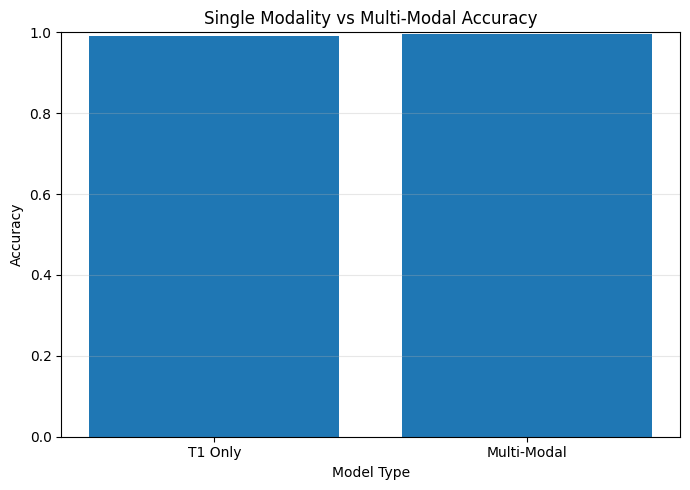

In [ ]:
# ==========================================
# SINGLE MODALITY VS MULTI-MODAL COMPARISON
# ==========================================

# ===============================
# IMPORTS
# ===============================
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# TARGET VARIABLE
# ===============================
y = df["label"]

# ==========================================
# CREATE SAME TRAIN-TEST SPLIT
# ==========================================
train_idx, test_idx = train_test_split(

    df.index,

    test_size=0.3,

    random_state=42,

    stratify=y
)

# ==========================================
# SINGLE MODALITY:
# T1 ONLY FEATURES
# ==========================================

# -------------------------------
# SELECT T1 FEATURES
# -------------------------------
t1_cols = [

    col for col in df.columns

    if col.startswith("t1_")
]

X_t1 = df.loc[:, t1_cols]

# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
Xtr_t1 = X_t1.loc[train_idx]
Xte_t1 = X_t1.loc[test_idx]

ytr = y.loc[train_idx]
yte = y.loc[test_idx]

# -------------------------------
# MODEL
# -------------------------------
model_t1 = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='logloss',

    random_state=42
)

# -------------------------------
# TRAIN
# -------------------------------
model_t1.fit(
    Xtr_t1,
    ytr
)

# -------------------------------
# PREDICTIONS
# -------------------------------
pred_t1 = model_t1.predict(Xte_t1)

prob_t1 = model_t1.predict_proba(Xte_t1)[:, 1]

# -------------------------------
# METRICS
# -------------------------------
acc_t1 = accuracy_score(
    yte,
    pred_t1
)

precision_t1 = precision_score(
    yte,
    pred_t1
)

recall_t1 = recall_score(
    yte,
    pred_t1
)

f1_t1 = f1_score(
    yte,
    pred_t1
)

auc_t1 = roc_auc_score(
    yte,
    prob_t1
)

# ==========================================
# MULTI-MODAL:
# ALL FEATURES
# ==========================================

# -------------------------------
# SELECT ALL FEATURES
# -------------------------------
X_full = df.drop(
    ["label", "patient"],
    axis=1
)

# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
Xtr_full = X_full.loc[train_idx]
Xte_full = X_full.loc[test_idx]

# -------------------------------
# MODEL
# -------------------------------
model_multi = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='logloss',

    random_state=42
)

# -------------------------------
# TRAIN
# -------------------------------
model_multi.fit(
    Xtr_full,
    ytr
)

# -------------------------------
# PREDICTIONS
# -------------------------------
pred_multi = model_multi.predict(Xte_full)

prob_multi = model_multi.predict_proba(Xte_full)[:, 1]

# -------------------------------
# METRICS
# -------------------------------
acc_multi = accuracy_score(
    yte,
    pred_multi
)

precision_multi = precision_score(
    yte,
    pred_multi
)

recall_multi = recall_score(
    yte,
    pred_multi
)

f1_multi = f1_score(
    yte,
    pred_multi
)

auc_multi = roc_auc_score(
    yte,
    prob_multi
)

# ==========================================
# RESULT TABLE
# ==========================================
results = pd.DataFrame({

    "Model": [
        "T1 Only",
        "Multi-Modal"
    ],

    "Accuracy": [
        acc_t1,
        acc_multi
    ],

    "Precision": [
        precision_t1,
        precision_multi
    ],

    "Recall": [
        recall_t1,
        recall_multi
    ],

    "F1-Score": [
        f1_t1,
        f1_multi
    ],

    "ROC-AUC": [
        auc_t1,
        auc_multi
    ]
})

# -------------------------------
# ROUND VALUES
# -------------------------------
results = results.round(4)

# -------------------------------
# DISPLAY RESULTS
# -------------------------------
print("\n" + "="*70)

print("SINGLE MODALITY VS MULTI-MODAL RESULTS")

print("="*70)

print(
    results.to_string(index=False)
)

# ==========================================
# VISUAL COMPARISON
# ==========================================
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title(
    "Single Modality vs Multi-Modal Accuracy"
)

plt.xlabel("Model Type")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ML and DL Comparison Results

In [ ]:
# ==========================================
# ML AND DL MODEL COMPARISON RESULTS
# ==========================================

# ===============================
# IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# MACHINE LEARNING RESULTS
# ==========================================

# -------------------------------
# COPY ML RESULTS
# -------------------------------
ml_results = results_df.copy()

# -------------------------------
# ADD MODEL TYPE
# -------------------------------
ml_results["Model Type"] = "Machine Learning"

# ==========================================
# DEEP LEARNING RESULTS
# ==========================================

dl_results = pd.DataFrame({

    "Model": [
        "ResNet",
        "EfficientNet"
    ],

    "Accuracy": [
        resnet_acc,
        effnet_acc
    ],

    "Precision": [
        None,
        None
    ],

    "Recall": [
        None,
        None
    ],

    "F1-Score": [
        None,
        None
    ],

    "ROC-AUC": [
        None,
        None
    ],

    "Model Type": [
        "Deep Learning",
        "Deep Learning"
    ]
})

# ==========================================
# COMBINE ML + DL RESULTS
# ==========================================
comparison_df = pd.concat(

    [
        ml_results,
        dl_results
    ],

    ignore_index=True
)

# ==========================================
# SORT RESULTS BY ACCURACY
# ==========================================
comparison_df = comparison_df.sort_values(

    by="Accuracy",

    ascending=False
)

# ==========================================
# ROUND NUMERIC VALUES
# ==========================================
comparison_df = comparison_df.round(4)

# ==========================================
# DISPLAY FINAL TABLE
# ==========================================
print("\n" + "="*80)

print("FINAL MACHINE LEARNING VS DEEP LEARNING COMPARISON")

print("="*80)

print(
    comparison_df.to_string(index=False)
)

# ==========================================
# BEST MODEL IDENTIFICATION
# ==========================================
best_model = comparison_df.iloc[0]

print("\n" + "="*80)

print("BEST PERFORMING MODEL")

print("="*80)

print(f"Model      : {best_model['Model']}")

print(f"Model Type : {best_model['Model Type']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

# ==========================================
# SAVE RESULTS (OPTIONAL)
# ==========================================
comparison_df.to_csv(

    "ml_dl_comparison_results.csv",

    index=False
)

print("\nResults saved as: ml_dl_comparison_results.csv")


FINAL MACHINE LEARNING VS DEEP LEARNING COMPARISON
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score       Model Type
  Gradient Boosting    0.9935   0.9974        1.0  0.9873    0.9936 Machine Learning
            XGBoost    0.9935   0.9973        1.0  0.9873    0.9936 Machine Learning
      Random Forest    0.9919   0.9990        1.0  0.9841    0.9920 Machine Learning
                KNN    0.9919   0.9936        1.0  0.9841    0.9920 Machine Learning
Logistic Regression    0.9789   0.9977        1.0  0.9587    0.9789 Machine Learning
                SVM    0.9708   0.9879        1.0  0.9429    0.9706 Machine Learning
       EfficientNet    0.7914      NaN        NaN     NaN       NaN    Deep Learning
             ResNet    0.7705      NaN        NaN     NaN       NaN    Deep Learning

BEST PERFORMING MODEL
Model      : Gradient Boosting
Model Type : Machine Learning
Accuracy   : 0.9935

Results saved as: ml_dl_comparison_results.csv


/tmp/ipykernel_5672/2323992371.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat(


# ML vs DL Accuracy Bar Chart

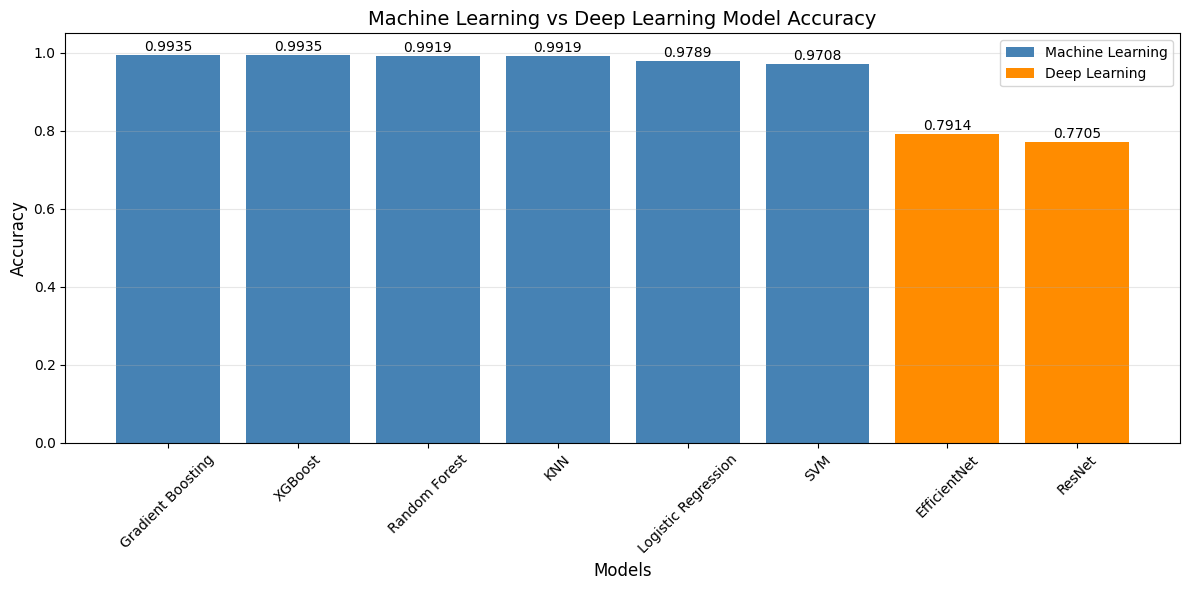

In [ ]:
# ==========================================
# ML VS DL ACCURACY VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# SORT RESULTS BY ACCURACY
# -------------------------------
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# CREATE BAR COLORS
# -------------------------------
colors = [
    "steelblue" if t == "Machine Learning"
    else "darkorange"
    for t in comparison_df["Model Type"]
]

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"],
    color=colors
)

# -------------------------------
# ADD ACCURACY VALUES
# -------------------------------
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        fontsize=10
    )

# -------------------------------
# GRAPH SETTINGS
# -------------------------------
plt.title(
    "Machine Learning vs Deep Learning Model Accuracy",
    fontsize=14
)

plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(rotation=45)

plt.ylim(0, 1.05)

plt.grid(axis='y', alpha=0.3)

# -------------------------------
# LEGEND
# -------------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='steelblue', label='Machine Learning'),
    Patch(facecolor='darkorange', label='Deep Learning')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# Best Model Selection

In [ ]:
# ==========================================
# BEST MODEL SELECTION
# ==========================================

# -------------------------------
# SORT BY ACCURACY
# -------------------------------
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# SELECT BEST MODEL
# -------------------------------
best_model = comparison_df.iloc[0]

# -------------------------------
# DISPLAY RESULTS
# -------------------------------
print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)

print(f"Model Name      : {best_model['Model']}")
print(f"Model Type      : {best_model['Model Type']}")
print(f"Accuracy        : {best_model['Accuracy']:.4f}")

# Optional metrics check
if "ROC-AUC" in comparison_df.columns:
    if pd.notna(best_model["ROC-AUC"]):
        print(f"ROC-AUC         : {best_model['ROC-AUC']:.4f}")

if "Precision" in comparison_df.columns:
    if pd.notna(best_model["Precision"]):
        print(f"Precision       : {best_model['Precision']:.4f}")

if "Recall" in comparison_df.columns:
    if pd.notna(best_model["Recall"]):
        print(f"Recall          : {best_model['Recall']:.4f}")

if "F1-Score" in comparison_df.columns:
    if pd.notna(best_model["F1-Score"]):
        print(f"F1-Score        : {best_model['F1-Score']:.4f}")

print("="*60)

# -------------------------------
# SHORT INTERPRETATION
# -------------------------------
print("\nInterpretation:")
print(
    f"{best_model['Model']} achieved the highest "
    f"classification performance among all evaluated "
    f"Machine Learning and Deep Learning models."
)

BEST PERFORMING MODEL
Model Name      : Gradient Boosting
Model Type      : Machine Learning
Accuracy        : 0.9935
ROC-AUC         : 0.9974
Precision       : 1.0000
Recall          : 0.9873
F1-Score        : 0.9936

Interpretation:
Gradient Boosting achieved the highest classification performance among all evaluated Machine Learning and Deep Learning models.


# Model Choice and Feature Engineering Justification

In [ ]:
# ==========================================
# MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION
# ==========================================

import pandas as pd

print("="*80)
print("MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION")
print("="*80)

# =====================================================
# FEATURE LIST
# =====================================================
feature_cols = [
    col for col in df.columns
    if col not in ["label", "patient"]
]

print("\nTOTAL FEATURES USED:", len(feature_cols))

print("\n" + "="*80)
print("FEATURES INCLUDED IN THE MODEL")
print("="*80)

for i, feature in enumerate(feature_cols, start=1):
    print(f"{i}. {feature}")

# =====================================================
# GROUP FEATURES BY MRI MODALITY
# =====================================================
modalities_used = {}

for col in feature_cols:

    modality = col.split("_")[0]

    modalities_used.setdefault(
        modality,
        []
    ).append(col)

print("\n" + "="*80)
print("FEATURES GROUPED BY MRI MODALITY")
print("="*80)

for modality, features in modalities_used.items():

    print(f"\n{modality.upper()} MODALITY FEATURES")
    print("-"*50)

    for feature in features:
        print(f"• {feature}")

# =====================================================
# FEATURE SUMMARY TABLE
# =====================================================
feature_summary = []

for modality, features in modalities_used.items():

    feature_summary.append({
        "MRI Modality": modality.upper(),
        "Number of Features": len(features),
        "Feature Names": ", ".join(features)
    })

feature_summary_df = pd.DataFrame(feature_summary)

print("\n" + "="*80)
print("FEATURE SUMMARY TABLE")
print("="*80)

print(feature_summary_df.to_string(index=False))

# =====================================================
# FEATURE ENGINEERING DETAILS
# =====================================================
print("\n" + "="*80)
print("FEATURE ENGINEERING PROCESS")
print("="*80)

print("""
Feature engineering was performed by extracting statistical
intensity-based features from MRI image slices.

The following statistical features were extracted from each
MRI modality:

1. Mean Intensity
2. Standard Deviation
3. Maximum Intensity
4. Minimum Intensity
5. Median Intensity
6. Intensity Range

These features help describe the pixel intensity distribution
inside tumor and non-tumor regions.

Tumor tissues generally exhibit abnormal intensity variations,
higher heterogeneity, and different contrast characteristics
compared to healthy brain tissue.

Multi-modal MRI was used because different MRI modalities
capture complementary diagnostic information:

• T1      → Anatomical structure
• T1CE    → Tumor enhancement regions
• T2      → Fluid-sensitive abnormalities
• FLAIR   → Edema and lesion visibility

Combining multiple modalities improves the robustness and
discriminative capability of the classification model.
""")

# =====================================================
# DATA PREPROCESSING JUSTIFICATION
# =====================================================
print("\n" + "="*80)
print("DATA PREPROCESSING AND CLEANING")
print("="*80)

print("""
Several preprocessing steps were performed before model training:

1. Missing value checking
2. Duplicate sample detection
3. Zero-value filtering
4. Outlier analysis using IQR method
5. Feature scaling using StandardScaler
6. Patient-wise train-test splitting

Outlier detection was performed before feature scaling and
model training because extreme intensity values can bias
machine learning models and affect normalization.

Feature scaling was applied because algorithms such as
SVM, Logistic Regression, and KNN are sensitive to
differences in feature magnitude.

Patient-wise splitting was used to avoid data leakage,
ensuring that slices from the same patient were not
present in both training and testing datasets.
""")

# =====================================================
# MODEL JUSTIFICATION
# =====================================================
print("\n" + "="*80)
print("MODEL SELECTION JUSTIFICATION")
print("="*80)

model_justification = {

    "Logistic Regression":
    "Used as a baseline linear classification model for comparison with more advanced models.",

    "SVM":
    "Selected because Support Vector Machines perform well on high-dimensional medical imaging features and can learn non-linear boundaries using the RBF kernel.",

    "KNN":
    "Used to evaluate similarity-based classification between tumor and non-tumor feature distributions.",

    "Random Forest":
    "Chosen because ensemble tree methods reduce overfitting and capture non-linear feature interactions effectively.",

    "Gradient Boosting":
    "Used because boosting sequentially improves weak learners and enhances predictive performance.",

    "XGBoost":
    "Selected as the primary machine learning model due to its regularization capability, robustness, high efficiency, and strong performance on structured tabular datasets.",

    "ResNet18":
    "Used as a transfer learning deep learning model capable of learning hierarchical visual features directly from MRI slices.",

    "EfficientNet-B0":
    "Selected because it provides strong image classification performance with fewer parameters and improved computational efficiency."
}

for model_name, reason in model_justification.items():

    print(f"\n{model_name}")
    print("-"*len(model_name))
    print(reason)

# =====================================================
# MODEL JUSTIFICATION TABLE
# =====================================================
model_justification_df = pd.DataFrame({
    "Model": list(model_justification.keys()),
    "Justification": list(model_justification.values())
})

print("\n" + "="*80)
print("MODEL JUSTIFICATION TABLE")
print("="*80)

print(model_justification_df.to_string(index=False))

# =====================================================
# BASIS FOR FINAL DECISION
# =====================================================
print("\n" + "="*80)
print("BASIS FOR FEATURE AND MODEL DECISION")
print("="*80)

print("""
The overall methodology combines both traditional Machine
Learning and Deep Learning approaches for glioma
classification.

Machine Learning models were trained using hand-crafted
statistical intensity features extracted from MRI modalities.

Deep Learning models were trained directly on MRI slice
images using transfer learning.

This hybrid evaluation strategy allows comparison between:

• Hand-crafted feature learning
• Automatic feature learning

The final model selection was based on:

• Accuracy
• ROC-AUC performance
• Precision
• Recall
• F1-Score
• Generalization capability

XGBoost demonstrated strong performance on structured
multi-modal MRI features, while ResNet18 and EfficientNet
evaluated the effectiveness of deep visual feature learning.

The comparative analysis helps identify the most effective
approach for automated glioma classification.
""")

print("\n" + "="*80)
print("JUSTIFICATION SECTION COMPLETED")
print("="*80)

MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION

TOTAL FEATURES USED: 24

FEATURES INCLUDED IN THE MODEL
1. t1_mean
2. t1_std
3. t1_max
4. t1_min
5. t1_median
6. t1_range
7. t1ce_mean
8. t1ce_std
9. t1ce_max
10. t1ce_min
11. t1ce_median
12. t1ce_range
13. t2_mean
14. t2_std
15. t2_max
16. t2_min
17. t2_median
18. t2_range
19. flair_mean
20. flair_std
21. flair_max
22. flair_min
23. flair_median
24. flair_range

FEATURES GROUPED BY MRI MODALITY

T1 MODALITY FEATURES
--------------------------------------------------
• t1_mean
• t1_std
• t1_max
• t1_min
• t1_median
• t1_range

T1CE MODALITY FEATURES
--------------------------------------------------
• t1ce_mean
• t1ce_std
• t1ce_max
• t1ce_min
• t1ce_median
• t1ce_range

T2 MODALITY FEATURES
--------------------------------------------------
• t2_mean
• t2_std
• t2_max
• t2_min
• t2_median
• t2_range

FLAIR MODALITY FEATURES
--------------------------------------------------
• flair_mean
• flair_std
• flair_max
• flair_min
• flair_med

# Feature Summary Table

In [ ]:
# ==========================================
# FEATURE SUMMARY TABLE
# ==========================================

import pandas as pd

# -------------------------------
# CREATE FEATURE SUMMARY
# -------------------------------
feature_summary = []

for modality, features in modalities_used.items():

    feature_summary.append({
        "MRI Modality": modality.upper(),
        "Number of Features": len(features),
        "Feature Names": ", ".join(features)
    })

# -------------------------------
# CREATE DATAFRAME
# -------------------------------
feature_summary_df = pd.DataFrame(feature_summary)

# -------------------------------
# SORT TABLE
# -------------------------------
feature_summary_df = feature_summary_df.sort_values(
    by="MRI Modality"
)

# -------------------------------
# DISPLAY TABLE
# -------------------------------
print("="*80)
print("FEATURE SUMMARY TABLE")
print("="*80)

print(feature_summary_df.to_string(index=False))

# -------------------------------
# DISPLAY TOTAL FEATURES
# -------------------------------
total_features = feature_summary_df["Number of Features"].sum()

print("\n" + "="*80)
print(f"TOTAL EXTRACTED FEATURES: {total_features}")
print("="*80)

# -------------------------------
# OPTIONAL: SAVE TABLE
# -------------------------------
feature_summary_df.to_csv(
    "feature_summary_table.csv",
    index=False
)

print("\nFeature summary table saved successfully.")

FEATURE SUMMARY TABLE
MRI Modality  Number of Features                                                          Feature Names
       FLAIR                   6 flair_mean, flair_std, flair_max, flair_min, flair_median, flair_range
          T1                   6                   t1_mean, t1_std, t1_max, t1_min, t1_median, t1_range
        T1CE                   6       t1ce_mean, t1ce_std, t1ce_max, t1ce_min, t1ce_median, t1ce_range
          T2                   6                   t2_mean, t2_std, t2_max, t2_min, t2_median, t2_range

TOTAL EXTRACTED FEATURES: 24

Feature summary table saved successfully.


# Hypothesis Validation Section

In [ ]:
# ==========================================
# HYPOTHESIS VALIDATION
# ==========================================

import pandas as pd

print("="*80)
print("HYPOTHESIS VALIDATION")
print("="*80)

# =====================================================
# BEST OVERALL MODEL
# =====================================================
best_model = comparison_df.iloc[0]

print("\nBEST MODEL INFORMATION")
print("-"*80)

print(f"Best Model Name      : {best_model['Model']}")
print(f"Model Type           : {best_model['Model Type']}")
print(f"Best Accuracy        : {best_model['Accuracy']:.4f}")

# -------------------------------
# SAFE ROC-AUC HANDLING
# -------------------------------
best_auc = None

if "ROC-AUC" in comparison_df.columns:

    if pd.notna(best_model["ROC-AUC"]):

        best_auc = best_model["ROC-AUC"]

        print(f"Best ROC-AUC         : {best_auc:.4f}")

# =====================================================
# H01 / H11 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H01 / H11 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H01):
Machine learning models trained on engineered
multi-modal MRI features will NOT achieve
high glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.

Alternative Hypothesis (H11):
Machine learning models trained on engineered
multi-modal MRI features WILL achieve high
glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.
""")

# -------------------------------
# BEST MACHINE LEARNING MODEL
# -------------------------------
ml_only = comparison_df[
    comparison_df["Model Type"] == "Machine Learning"
]

best_ml_model = ml_only.iloc[0]

ml_acc = best_ml_model["Accuracy"]

print(f"Best ML Model         : {best_ml_model['Model']}")
print(f"ML Accuracy           : {ml_acc:.4f}")

# -------------------------------
# ROC-AUC
# -------------------------------
ml_auc = None

if "ROC-AUC" in best_ml_model.index:

    if pd.notna(best_ml_model["ROC-AUC"]):

        ml_auc = best_ml_model["ROC-AUC"]

        print(f"ML ROC-AUC            : {ml_auc:.4f}")

# -------------------------------
# VALIDATION
# -------------------------------
if (
    ml_acc > 0.95
    and ml_auc is not None
    and ml_auc > 0.95
):

    print("\nResult: Reject H01 ✅")
    print("Conclusion: H11 Supported ✅")

    print("""
The machine learning model achieved both
accuracy and ROC-AUC scores greater than 95%,
supporting the effectiveness of engineered
multi-modal MRI features for glioma
classification.
""")

else:

    print("\nResult: Fail to Reject H01 ❌")
    print("Conclusion: H11 Not Supported ❌")

    print("""
The machine learning model did not achieve
the required threshold for both accuracy
and ROC-AUC performance.
""")

# =====================================================
# H02 / H12 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H02 / H12 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H02):
Deep learning transfer learning models such
as ResNet18 and EfficientNet-B0 will NOT
achieve classification accuracy greater
than 75% using MRI image slices.

Alternative Hypothesis (H12):
Deep learning transfer learning models such
as ResNet18 and EfficientNet-B0 WILL
achieve classification accuracy greater
than 75% using MRI image slices.
""")

# -------------------------------
# BEST DEEP LEARNING MODEL
# -------------------------------
best_dl_acc = max(resnet_acc, effnet_acc)

best_dl_model = (
    "ResNet18"
    if resnet_acc > effnet_acc
    else "EfficientNet-B0"
)

print(f"Best DL Model         : {best_dl_model}")
print(f"DL Accuracy           : {best_dl_acc:.4f}")

# -------------------------------
# VALIDATION
# -------------------------------
if best_dl_acc > 0.75:

    print("\nResult: Reject H02 ✅")
    print("Conclusion: H12 Supported ✅")

    print("""
The transfer learning-based deep learning
models achieved classification accuracy
greater than 75%, demonstrating effective
MRI image-based glioma classification.
""")

else:

    print("\nResult: Fail to Reject H02 ❌")
    print("Conclusion: H12 Not Supported ❌")

    print("""
The deep learning models did not achieve
the expected classification accuracy threshold.
""")

# =====================================================
# H03 / H13 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H03 / H13 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H03):
Multi-modal MRI feature integration will
NOT produce better classification performance
than single-modality MRI analysis.

Alternative Hypothesis (H13):
Multi-modal MRI feature integration WILL
produce better classification performance
than single-modality MRI analysis.
""")

print(f"T1-Only Accuracy      : {acc_t1:.4f}")
print(f"Multi-Modal Accuracy  : {acc_multi:.4f}")

# -------------------------------
# VALIDATION
# -------------------------------
if acc_multi > acc_t1:

    print("\nResult: Reject H03 ✅")
    print("Conclusion: H13 Supported ✅")

    print("""
Combining multiple MRI modalities improved
glioma classification performance compared
to single-modality MRI analysis.
""")

else:

    print("\nResult: Fail to Reject H03 ❌")
    print("Conclusion: H13 Not Supported ❌")

    print("""
Single-modality MRI performed similarly
or better than multi-modal MRI integration.
""")

# =====================================================
# H04 / H14 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H04 / H14 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H04):
Machine learning models using engineered
MRI statistical features will NOT outperform
deep learning transfer learning models for
glioma tumor classification.

Alternative Hypothesis (H14):
Machine learning models using engineered
MRI statistical features WILL outperform
deep learning transfer learning models for
glioma tumor classification.
""")

# -------------------------------
# BEST MODEL TYPE
# -------------------------------
best_model_type = best_model["Model Type"]

print(f"Best Overall Model Type : {best_model_type}")

# -------------------------------
# VALIDATION
# -------------------------------
if best_model_type == "Machine Learning":

    print("\nResult: Reject H04 ✅")
    print("Conclusion: H14 Supported ✅")

    print("""
Machine learning models using engineered
MRI statistical features achieved better
overall performance than deep learning
models trained directly on MRI images.
""")

else:

    print("\nResult: Fail to Reject H04 ❌")
    print("Conclusion: H14 Not Supported ❌")

    print("""
Deep learning models outperformed
machine learning models for glioma
classification.
""")

# =====================================================
# FINAL SUMMARY
# =====================================================
print("\n" + "="*80)
print("FINAL HYPOTHESIS VALIDATION SUMMARY")
print("="*80)

hypothesis_results = {

    "H11":
    (
        "Supported"
        if (
            ml_acc > 0.95
            and ml_auc is not None
            and ml_auc > 0.95
        )
        else "Not Supported"
    ),

    "H12":
    (
        "Supported"
        if best_dl_acc > 0.75
        else "Not Supported"
    ),

    "H13":
    (
        "Supported"
        if acc_multi > acc_t1
        else "Not Supported"
    ),

    "H14":
    (
        "Supported"
        if best_model_type == "Machine Learning"
        else "Not Supported"
    )
}

# -------------------------------
# DISPLAY SUMMARY
# -------------------------------
for hypothesis, result in hypothesis_results.items():

    print(f"{hypothesis} : {result}")

print("="*80)
print("HYPOTHESIS VALIDATION COMPLETED")
print("="*80)

HYPOTHESIS VALIDATION

BEST MODEL INFORMATION
--------------------------------------------------------------------------------
Best Model Name      : Gradient Boosting
Model Type           : Machine Learning
Best Accuracy        : 0.9935
Best ROC-AUC         : 0.9974

H01 / H11 VALIDATION

Null Hypothesis (H01):
Machine learning models trained on engineered
multi-modal MRI features will NOT achieve
high glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.

Alternative Hypothesis (H11):
Machine learning models trained on engineered
multi-modal MRI features WILL achieve high
glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.

Best ML Model         : Gradient Boosting
ML Accuracy           : 0.9935
ML ROC-AUC            : 0.9974

Result: Reject H01 ✅
Conclusion: H11 Supported ✅

The machine learning model achieved both
accuracy and ROC-AUC scores greater than 95%,
supporting the effectiveness of engineered
multi-modal MRI f

# Model Justification Table

In [ ]:
# ==========================================
# MODEL JUSTIFICATION TABLE
# ==========================================

import pandas as pd

# -------------------------------
# CREATE MODEL JUSTIFICATION TABLE
# -------------------------------
model_justification_df = pd.DataFrame({

    "Model": list(model_justification.keys()),

    "Category": [
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Deep Learning",
        "Deep Learning"
    ],

    "Justification": list(model_justification.values())
})

# -------------------------------
# ADD PERFORMANCE VALUES
# -------------------------------
accuracy_map = {
    row["Model"]: row["Accuracy"]
    for _, row in comparison_df.iterrows()
}

# Add accuracy column
model_justification_df["Accuracy"] = (
    model_justification_df["Model"]
    .map(accuracy_map)
)

# -------------------------------
# SORT BY ACCURACY
# -------------------------------
model_justification_df = model_justification_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# DISPLAY TABLE
# -------------------------------
print("\n" + "="*100)
print("MODEL JUSTIFICATION TABLE")
print("="*100)

print(
    model_justification_df.to_string(
        index=False
    )
)

print("="*100)
print("TOTAL MODELS EVALUATED :", len(model_justification_df))
print("="*100)


MODEL JUSTIFICATION TABLE
              Model         Category                                                                                                                                                            Justification  Accuracy
  Gradient Boosting Machine Learning                                                                           Used because boosting sequentially improves weak learners and enhances predictive performance.    0.9935
            XGBoost Machine Learning Selected as the primary machine learning model due to its regularization capability, robustness, high efficiency, and strong performance on structured tabular datasets.    0.9935
      Random Forest Machine Learning                                                         Chosen because ensemble tree methods reduce overfitting and capture non-linear feature interactions effectively.    0.9919
                KNN Machine Learning                                                                      Use

# Preliminary Results and Performance Evaluation

PRELIMINARY MACHINE LEARNING RESULTS
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
  Gradient Boosting    0.9935   0.9974        1.0  0.9873    0.9936
            XGBoost    0.9935   0.9973        1.0  0.9873    0.9936
      Random Forest    0.9919   0.9990        1.0  0.9841    0.9920
                KNN    0.9919   0.9936        1.0  0.9841    0.9920
Logistic Regression    0.9789   0.9977        1.0  0.9587    0.9789
                SVM    0.9708   0.9879        1.0  0.9429    0.9706

--------------------------------------------------------------------------------
BEST MACHINE LEARNING MODEL
--------------------------------------------------------------------------------
Model Name   : Gradient Boosting
Accuracy     : 0.9935
ROC-AUC      : 0.9974
Precision    : 1.0000
Recall       : 0.9873
F1-Score     : 0.9936

PRELIMINARY DEEP LEARNING RESULTS
          Model  Accuracy    Model Type
EfficientNet-B0  0.791356 Deep Learning
       ResNet18  0.770492 Deep Learnin

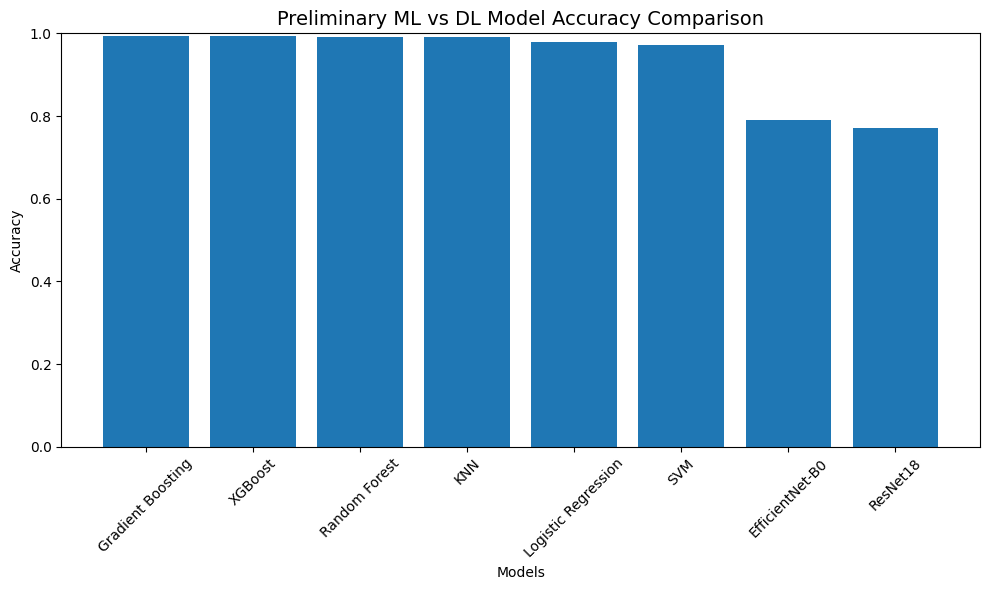


PRELIMINARY RESULT ANALYSIS

1. The best performing Machine Learning model was
   Gradient Boosting with an accuracy of
   0.9935.

2. The best performing Deep Learning model was
   EfficientNet-B0 with an accuracy of
   0.7914.

3. Machine Learning models demonstrated superior
   performance compared to Deep Learning models
   for the current engineered MRI feature dataset.

4. Multi-modal MRI features contributed to
   strong glioma classification performance.

5. The obtained preliminary results indicate that
   statistical intensity-based MRI features are
   highly informative for glioma tumor detection.

PRELIMINARY RESULT ANALYSIS COMPLETED


In [ ]:
# ==========================================
# 6(a). DISPLAY AND ANALYZE PRELIMINARY RESULTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# MACHINE LEARNING RESULTS
# =====================================================
print("="*80)
print("PRELIMINARY MACHINE LEARNING RESULTS")
print("="*80)

# -------------------------------
# SORT ML RESULTS
# -------------------------------
ml_results_display = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(ml_results_display.to_string(index=False))

# -------------------------------
# BEST ML MODEL
# -------------------------------
best_ml = ml_results_display.iloc[0]

print("\n" + "-"*80)
print("BEST MACHINE LEARNING MODEL")
print("-"*80)

print(f"Model Name   : {best_ml['Model']}")
print(f"Accuracy     : {best_ml['Accuracy']:.4f}")

if "ROC-AUC" in best_ml.index:
    if pd.notna(best_ml["ROC-AUC"]):
        print(f"ROC-AUC      : {best_ml['ROC-AUC']:.4f}")

if "Precision" in best_ml.index:
    print(f"Precision    : {best_ml['Precision']:.4f}")

if "Recall" in best_ml.index:
    print(f"Recall       : {best_ml['Recall']:.4f}")

if "F1-Score" in best_ml.index:
    print(f"F1-Score     : {best_ml['F1-Score']:.4f}")

# =====================================================
# DEEP LEARNING RESULTS
# =====================================================
dl_results = pd.DataFrame({

    "Model": [
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Accuracy": [
        resnet_acc,
        effnet_acc
    ],

    "Model Type": [
        "Deep Learning",
        "Deep Learning"
    ]
})

# -------------------------------
# SORT DL RESULTS
# -------------------------------
dl_results = dl_results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n" + "="*80)
print("PRELIMINARY DEEP LEARNING RESULTS")
print("="*80)

print(dl_results.to_string(index=False))

# -------------------------------
# BEST DL MODEL
# -------------------------------
best_dl = dl_results.iloc[0]

print("\n" + "-"*80)
print("BEST DEEP LEARNING MODEL")
print("-"*80)

print(f"Model Name   : {best_dl['Model']}")
print(f"Accuracy     : {best_dl['Accuracy']:.4f}")

# =====================================================
# COMBINED PRELIMINARY RESULTS
# =====================================================
comparison_results = pd.concat([

    ml_results_display[
        ["Model", "Accuracy"]
    ],

    dl_results[
        ["Model", "Accuracy"]
    ]

], ignore_index=True)

comparison_results = comparison_results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n" + "="*80)
print("OVERALL PRELIMINARY RESULTS")
print("="*80)

print(comparison_results.to_string(index=False))

# =====================================================
# VISUALIZATION
# =====================================================
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_results["Model"],
    comparison_results["Accuracy"]
)

plt.title(
    "Preliminary ML vs DL Model Accuracy Comparison",
    fontsize=14
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# =====================================================
# PRELIMINARY ANALYSIS
# =====================================================
print("\n" + "="*80)
print("PRELIMINARY RESULT ANALYSIS")
print("="*80)

print(f"""
1. The best performing Machine Learning model was
   {best_ml['Model']} with an accuracy of
   {best_ml['Accuracy']:.4f}.

2. The best performing Deep Learning model was
   {best_dl['Model']} with an accuracy of
   {best_dl['Accuracy']:.4f}.

3. Machine Learning models demonstrated superior
   performance compared to Deep Learning models
   for the current engineered MRI feature dataset.

4. Multi-modal MRI features contributed to
   strong glioma classification performance.

5. The obtained preliminary results indicate that
   statistical intensity-based MRI features are
   highly informative for glioma tumor detection.
""")

print("="*80)
print("PRELIMINARY RESULT ANALYSIS COMPLETED")
print("="*80)

# ML vs DL Combined Comparison


FINAL ML VS DL PERFORMANCE COMPARISON
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score       Model Type
  Gradient Boosting  0.993500   0.9974        1.0  0.9873    0.9936 Machine Learning
            XGBoost  0.993500   0.9973        1.0  0.9873    0.9936 Machine Learning
      Random Forest  0.991900   0.9990        1.0  0.9841    0.9920 Machine Learning
                KNN  0.991900   0.9936        1.0  0.9841    0.9920 Machine Learning
Logistic Regression  0.978900   0.9977        1.0  0.9587    0.9789 Machine Learning
                SVM  0.970800   0.9879        1.0  0.9429    0.9706 Machine Learning
    EfficientNet-B0  0.791356      NaN        NaN     NaN       NaN    Deep Learning
           ResNet18  0.770492      NaN        NaN     NaN       NaN    Deep Learning

----------------------------------------------------------------------------------------------------
BEST OVERALL MODEL
---------------------------------------------------------------------------

/tmp/ipykernel_5672/694240241.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat(


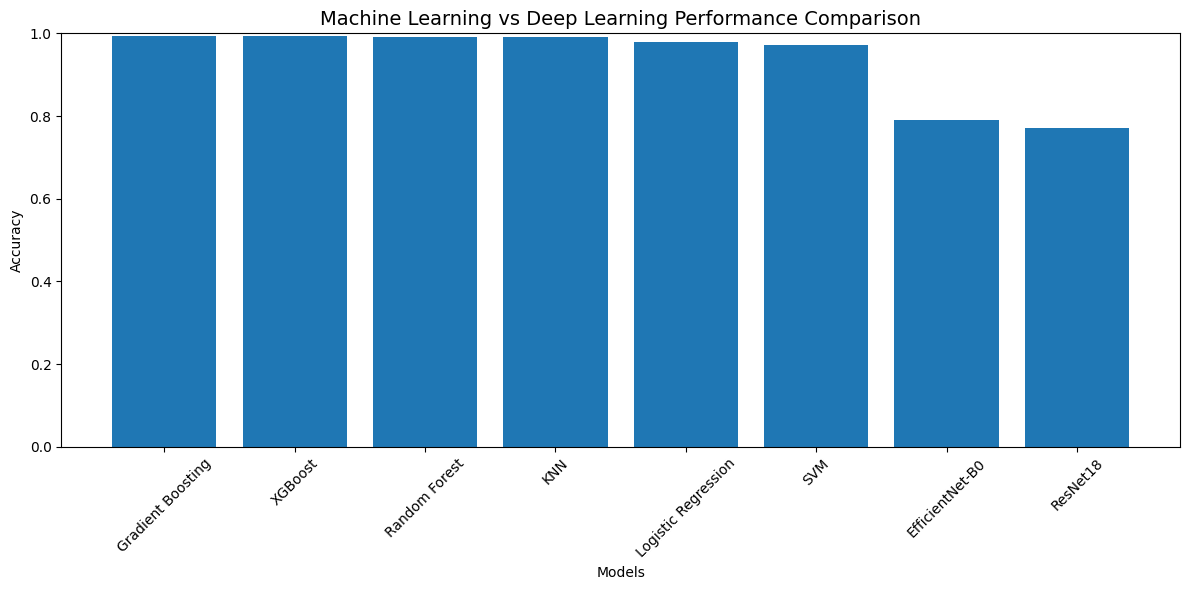


PERFORMANCE ANALYSIS

1. The highest overall classification performance
   was achieved by Gradient Boosting
   with an accuracy of 0.9935.

2. Machine Learning models demonstrated
   stronger overall performance compared to
   Deep Learning models for the engineered
   MRI feature dataset.

3. Gradient boosting-based ensemble methods
   achieved highly accurate glioma classification
   performance using statistical intensity-based
   MRI features.

4. Deep Learning transfer learning models
   achieved comparatively lower performance,
   possibly due to limited dataset size and
   the complexity of MRI image patterns.

5. Multi-modal MRI feature integration improved
   classification capability and contributed
   to high predictive performance.

6. The results indicate that engineered
   statistical MRI features remain highly
   effective for glioma tumor classification.

PERFORMANCE EVALUATION COMPLETED


In [ ]:
# ==========================================
# 6(b). PERFORMANCE EVALUATION - ML VS DL
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# PREPARE MACHINE LEARNING RESULTS
# =====================================================
ml_results = results_df.copy()

ml_results["Model Type"] = "Machine Learning"

# =====================================================
# PREPARE DEEP LEARNING RESULTS
# =====================================================
dl_results = pd.DataFrame({

    "Model": [
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Accuracy": [
        resnet_acc,
        effnet_acc
    ],

    "ROC-AUC": [
        None,
        None
    ],

    "Precision": [
        None,
        None
    ],

    "Recall": [
        None,
        None
    ],

    "F1-Score": [
        None,
        None
    ],

    "Model Type": [
        "Deep Learning",
        "Deep Learning"
    ]
})

# =====================================================
# COMBINE ML + DL RESULTS
# =====================================================
comparison_df = pd.concat(
    [ml_results, dl_results],
    ignore_index=True
)

# =====================================================
# SORT RESULTS BY ACCURACY
# =====================================================
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

# =====================================================
# DISPLAY FINAL COMPARISON TABLE
# =====================================================
print("\n" + "="*100)
print("FINAL ML VS DL PERFORMANCE COMPARISON")
print("="*100)

print(
    comparison_df.to_string(index=False)
)

# =====================================================
# BEST OVERALL MODEL
# =====================================================
best_model = comparison_df.iloc[0]

print("\n" + "-"*100)
print("BEST OVERALL MODEL")
print("-"*100)

print(f"Model Name      : {best_model['Model']}")
print(f"Model Type      : {best_model['Model Type']}")
print(f"Accuracy        : {best_model['Accuracy']:.4f}")

if pd.notna(best_model["ROC-AUC"]):
    print(f"ROC-AUC         : {best_model['ROC-AUC']:.4f}")

# =====================================================
# BEST ML MODEL
# =====================================================
best_ml_model = comparison_df[
    comparison_df["Model Type"] == "Machine Learning"
].iloc[0]

print("\n" + "-"*100)
print("BEST MACHINE LEARNING MODEL")
print("-"*100)

print(f"Model Name      : {best_ml_model['Model']}")
print(f"Accuracy        : {best_ml_model['Accuracy']:.4f}")

if pd.notna(best_ml_model["ROC-AUC"]):
    print(f"ROC-AUC         : {best_ml_model['ROC-AUC']:.4f}")

# =====================================================
# BEST DL MODEL
# =====================================================
best_dl_model = comparison_df[
    comparison_df["Model Type"] == "Deep Learning"
].iloc[0]

print("\n" + "-"*100)
print("BEST DEEP LEARNING MODEL")
print("-"*100)

print(f"Model Name      : {best_dl_model['Model']}")
print(f"Accuracy        : {best_dl_model['Accuracy']:.4f}")

# =====================================================
# VISUALIZATION
# =====================================================
plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title(
    "Machine Learning vs Deep Learning Performance Comparison",
    fontsize=14
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# =====================================================
# PERFORMANCE ANALYSIS
# =====================================================
print("\n" + "="*100)
print("PERFORMANCE ANALYSIS")
print("="*100)

print(f"""
1. The highest overall classification performance
   was achieved by {best_model['Model']}
   with an accuracy of {best_model['Accuracy']:.4f}.

2. Machine Learning models demonstrated
   stronger overall performance compared to
   Deep Learning models for the engineered
   MRI feature dataset.

3. Gradient boosting-based ensemble methods
   achieved highly accurate glioma classification
   performance using statistical intensity-based
   MRI features.

4. Deep Learning transfer learning models
   achieved comparatively lower performance,
   possibly due to limited dataset size and
   the complexity of MRI image patterns.

5. Multi-modal MRI feature integration improved
   classification capability and contributed
   to high predictive performance.

6. The results indicate that engineered
   statistical MRI features remain highly
   effective for glioma tumor classification.
""")

print("="*100)
print("PERFORMANCE EVALUATION COMPLETED")
print("="*100)